# 삼박자 - 최종 프로젝트

코드 진행상황

In [1]:
# 20250109 샘플 데이터셋 전처리 밑작업
# 20250113 전처리 코드 정리 & EDA 시각화 추가
# 20250115 skinsort 브랜드 관련 데이터 추가
# 20250116 아마존 최종 데이터로 전처리 등 코드 수정
# 20250120 중간정리본 1차 정리 완료
# 20250120 선정 브랜드 및 성분 관련 작업 추가 + 코드 진행에 따른 주석 추가
# 20250121 토픽 모델링 코드 추가 + 테스트 진행 
# 20250121 추가 EDA 진행을 위한 코드 + 상관분석 및 집단 간 차이 코드 추가 (예정)

# PART 1: Data Preprocessing

### Import library & Load data

In [1]:
# 필수 라이브러리 불러오기
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import ast
import datetime
import re
import string
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# 머신러닝 군집분석을 위한 라이브러리 불러오기
from sklearn.preprocessing import StandardScaler
from yellowbrick.cluster import KElbowVisualizer
from yellowbrick.cluster import intercluster_distance
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings('ignore')

CWD = os.getcwd()
DATA_PATH = "./dataset/"
print("현재 경로: ", CWD)

def load_data(data_path, file):
    path = os.path.join(data_path, file)
    return pd.read_csv(path)

#item_df = load_data(DATA_PATH,'items_0116.csv' )
#review_df = load_data(DATA_PATH,'reviews_0116.csv')
#skinsort_df = load_data(DATA_PATH,'skinsort_0115.csv')

현재 경로:  c:\Users\dav74\Desktop\스파르타코딩\데이터 분석 실무 과정\DATA_4기\study\최종 프로젝트


In [4]:
# 데이터셋 불러오기
dr_items = pd.read_csv('Dr_jart_items.csv')
dr_reviews = pd.read_csv('Dr_jart_reviews.csv')
cs_items = pd.read_csv('cosrx_items.csv')
cs_reviews = pd.read_csv('cosrx_reviews.csv')
if_items = pd.read_csv('imfrom_items.csv')
if_reviews = pd.read_csv('imfrom_reviews.csv')
bj_items = pd.read_csv('joseon_items.csv')
bj_reviews = pd.read_csv('joseon_reviews.csv')
pu_items = pd.read_csv('purito_items.csv')
pu_reviews = pd.read_csv('purito_reviews.csv')
skinsort = pd.read_csv('datasheet.csv')

In [4]:
# 전체적인 데이터 정보 EDA
def eda_overveiw(df):
    
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    
    print(f"\n=================== DATA OVERVIEW ===================")
    
    # 데이터 상단부 확인
    print("\n----------------- Head -----------------")
    print(df.head())
    print("=" * 60)

    # 데이터 정보 및 크기 확인
    print("\n--------------- Information ---------------")
    print(df.info())
    print(f"\nSize: {df.size}")
    print(f"Shape: {df.shape}")
    print("=" * 60)

    # 결측치 확인
    print("\n--------------- Missing Values ---------------")
    print(df.isnull().sum())
    print("=" * 60)

    # 중복값 확인
    print("\n--------------- Duplicate Values ---------------")
    print(df.duplicated().value_counts())
    print("=" * 60)

    # 데이터 기술통계량 확인 (int, float type)
    print("\n------------ Descriptive Statistics (Numeric) ------------")
    print(df.describe())
    print("=" * 60)

    # 데이터 기술통계량 확인 (object type)
    print("\n------------ Descriptive Statistics (Categorical) ------------")
    
    try:
        print(df.describe(include=[object]))
        
    except:  
        object_cols = df.select_dtypes(include=['object']).columns
        error_cols = []
        
        for col in object_cols:
            if df[col].apply(lambda x: isinstance(x, (list, dict))).any():
                error_cols.append(col)
        print(f"{error_cols} Excluded")
        print(df.loc[:, ~df.columns.isin(error_cols)].describe(include=[object]))
    
    print("=" * 60)
    
eda_overveiw(cs_items)


=================== DATA OVERVIEW ===================

----------------- Head -----------------
         ASIN                                              title  order  \
0  B00OZ63ODA  COSRX AHA/BHA Treatment Toner 5.07 fl.oz/ 150m...     39   
1  B00OZ6W8DW  [Cosrx] Salicylic Acid Daily Gentle Cleanser 1...     36   
2  B00OZ9MKDM  COSRX Hyaluronic Acid Toner, 3.38 fl.oz / 100m...     31   
3  B00OZEJ8R8  COSRX Niacinamide 2% + BHA 4% Blackhead Exfoli...     25   
4  B00PBX3L7K  COSRX Snail Mucin 96% Power Repairing Essence ...      1   

             category     brand  price global_rating_count  \
0  Skin Care Products     COSRX  11.29                6087   
1  Skin Care Products     COSRX  13.80                1878   
2  Skin Care Products     COSRX  16.30                 975   
3  Skin Care Products     COSRX  16.38                3554   
4  Skin Care Products  No brand  17.97               78392   

                                         description     Special_Feature  \
0  

### Data Cleaning

> 결측치 처리

#### copy original data

In [7]:
# 분석 & 전처리용으로 원본 데이터 복사
dr_items_copy = dr_items.copy()
dr_reviews_copy = dr_reviews.copy()
cs_items_copy = cs_items.copy()
cs_reviews_copy = cs_reviews.copy()
if_items_copy = if_items.copy()
if_reviews_copy = if_reviews.copy()
bj_items_copy = bj_items.copy()
bj_reviews_copy = bj_reviews.copy()
pu_items_copy = pu_items.copy()
pu_reviews_copy = pu_reviews.copy()
skinsort_copy = skinsort.copy()

In [14]:
# 데이터 전처리
# 'brand'가 없거나 다른 데이터 확인 / 각 파일마다 다르게 정리하기!
# 이유 - 브랜드별 아이템만 추출했기 때문 + 세부사항에 브랜드명 작성되어 있으니 그것보고 판단

# 브랜드 명 변경
brand_list = ['Dr.Jart+', 'COSRX', "I'm from", 'Beauty of Joseon','PURITO']
dr_items_copy['brand'].replace('No brand', brand_list[0], inplace=True)
cs_items_copy['brand'].replace('No brand', brand_list[1], inplace=True)
if_items_copy['brand'].replace('No brand', brand_list[2], inplace=True)
bj_items_copy['brand'].replace('No brand', brand_list[3], inplace=True)
pu_items_copy['brand'].replace('No brand', brand_list[4], inplace=True)

In [15]:
# items_df들의 컬럼 수정을 위해 df를 list에 포함시키기
items_list = [dr_items_copy, cs_items_copy, if_items_copy, bj_items_copy, pu_items_copy]

# reviews_df들의 컬럼 수정을 위해 df를 list에 포함시키기
reviews_list = [dr_reviews_copy, cs_reviews_copy, if_reviews_copy, bj_reviews_copy, pu_reviews_copy]

In [16]:
# items_df들의 결측치 한번에 처리
def preprocess_items(df_items):
    
    df_items['best_sellers_rank_Feature'].replace('No result', np.nan, inplace=True)
    df_items['global_rating_count'].replace('No rating', np.nan, inplace=True)
    df_items['Special_Feature'].replace('No special feature', np.nan, inplace=True)

for i in range(len(items_list)):
    preprocess_items(items_list[i])

In [17]:
# reviews_df들의 결측치 한번에 처리
def preprocess_reviews(df_reviews):
    
    df_reviews['date'].replace('No date', np.nan, inplace=True)
    df_reviews['review_rating'].replace('No review', np.nan, inplace=True)

for i in range(len(reviews_list)):
    preprocess_reviews(reviews_list[i])

In [18]:
# review / reivew content가 없을 경우 제거
def dropna_reviews(reviews_df):
    reviews_df.dropna(inplace=True) # review_copy 는 뒤에 결측치 있으니까 불편해서, 여기서 미리 드롭하는 걸로 추가했습니다 
    reviews_df.reset_index(inplace=True)

In [25]:
# review data 결측치 제거
for i in range(len(reviews_list)):
    dropna_reviews(reviews_list[i])

In [10]:
# 필요한 코드인지 확인하기!
# 결측치 확인 및 전처리는 후순위로 미뤄서 진행하기! 위치 - EDA 앞에서 처리하기!
# 결측지 확인
# item_df에 대해서는 결측치 제거 미실시
# df = cs_items_copy
#print(df.isnull().sum())

#plt.close()
#plt.figure(figsize=(9,8))
#sns.heatmap(df.isnull(), cbar_kws={'label':'Missing Values'}, cmap='Oranges')
#plt.title('Missing Values in Dataset')

#plt.show()

In [ ]:
skinsort_copy.info()

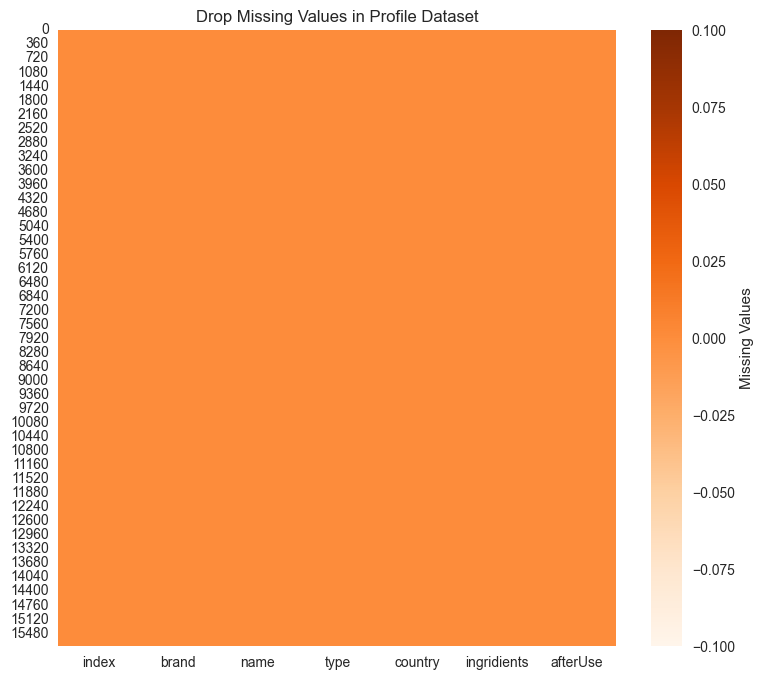

In [ ]:
# 결측치 처리
# skinsort
skinsort_copy.dropna(subset=['country','afterUse', 'type'], inplace=True)
skinsort_copy.reset_index(inplace=True)

# skinsort_copy.isnull().sum()

# 결측치 삭제 확인 시각화 -> 모두균일한 색으로 나오면 없는 것 !
plt.close()
plt.figure(figsize=(9,8))
sns.heatmap(skinsort_copy.isnull(), cbar_kws={'label':'Missing Values'}, cmap='Oranges')
plt.title('Drop Missing Values in Profile Dataset')
plt.show()

> 컬럼 별 전처리

In [28]:
# 컬럼 수정 한번에 진행하기!

# df_items : description 컬럼
def preprocess_description(df_items):
    
    for i in range(len(df_items)):
        description = ast.literal_eval(df_items.description[i])
        
        for key, value in description.items():
            if key not in df_items.columns:
                df_items[key] = np.nan
            df_items.loc[i, key] = value
            
    df_items.drop(columns=['description'], inplace=True)

# df_items : detail_dict 컬럼
def preprocess_detail_dict(df_items):
    
    for i in range(len(df_items)):
        detail_dict = ast.literal_eval(df_items.detail_dict[i])
        
        for key, value in detail_dict.items():
            if key not in df_items.columns:
                df_items[key] = np.nan
            df_items.loc[i, key] = value
            
    df_items.drop(columns=['detail_dict'], inplace=True)
    
# df_items : best_sellers_rank_Feature 컬럼을 세부 컬럼으로 나누기
def preprocess_best_sellers_col(df_items):

        for i in range(len(df_items)):
            try:
                value = df_items.best_sellers_rank_Feature[i]
                
                if pd.isna(value): #np.nan 인 애들
                    # print(f"{i}, {df_items.best_sellers_rank_Feature[i]} Passed")
                    continue
                
                if isinstance(value, float): # float 타입인 애들
                    value = str(value)
                    print(f"{i}, {df_items.best_sellers_rank_Feature[i]} Passed")
                
                cat_list = df_items.best_sellers_rank_Feature[i].split('#')
                
                df_items.loc[i, 'Category'] = cat_list[1]
                df_items.loc[i, 'Sub_Category'] = cat_list[2]
                
                detail_list = df_items.Category[i].split('in')
                
                df_items.loc[i, 'Category_Rank']= detail_list[0]
                df_items.loc[i, 'Category_Name']= detail_list[1]
                
                df_items.loc[i, 'Category_Name'] = df_items.Category_Name[i].split('(')[0]
                
                sub_list = df_items.Sub_Category[i].split('in')
                
                df_items.loc[i, 'Sub_Category_Rank']= sub_list[0]
                df_items.loc[i, 'Sub_Category_Name']= sub_list[1]
                    
            except Exception as e:
                print(f"{i}, {df_items.best_sellers_rank_Feature[i]} Passed")
                print(f"Error: {e}")
                
                continue
            
        df_items.drop(columns=['best_sellers_rank_Feature'], inplace=True)

In [29]:
# df_items들의 칼럼 수정 한번에 진행하기!
for i in range(len(items_list)) :
    preprocess_description(items_list[i])
    preprocess_detail_dict(items_list[i])
    preprocess_best_sellers_col(items_list[i])

In [30]:
# df_reviews : date, rating 컬럼
def preprocess_review_cols(df_reviews):

    for i in range(len(df_reviews)):
        
        try:
            
            if pd.isna(df_reviews.date[i]) or 'on' not in df_reviews.date[i]:
                # print(f"{i}, {df_reviews.date[i]} Passed")
                continue
            else:
                df_reviews.loc[i, 'review_date'] = df_reviews.date[i].split('on')[1]
                df_reviews.loc[i, 'review_date'] = pd.to_datetime(df_reviews.review_date[i])
            
            if pd.isna(df_reviews.review_rating[i]):
                print(f"{i}, {df_reviews.review_rating[i]} Passed")
                continue
            else:
                df_reviews.loc[i, 'review_rating'] = float(df_reviews.review_rating[i].split('out')[0])
        except Exception as e:
            print(f"{i}, {df_reviews.review_rating[i]}, Error: {e}")
            continue


In [31]:
# df_items들의 컬럼 한번에 수정하기
# 'review_date'를 날짜 형식으로 변경경
for i in range(len(reviews_list)) :
    preprocess_review_cols(reviews_list[i])
    reviews_list[i]['review_date'] = pd.to_datetime(reviews_list[i]['review_date'])
    reviews_list[i].drop(columns=['date'], inplace=True)
    reviews_list[i]['review_rating'] = pd.to_numeric(reviews_list[i]['review_rating'], errors='coerce', downcast='integer')

#### Base Data

##### 브랜드별 데이터 merge 결합 및 리뷰 데이터 정리 + EDA를 위한 통합 데이터셋으로 concat 결합

Merge 할 때 주의할점!
불필요한 컬럼에 대해서 제거하기!

In [16]:
# 데이터 결합 순서
# 각 브랜드별 item, review 데이터 결합
# Text preprocessing 까지 진행 후 concat으로 최종 결합

In [32]:
# 브랜드별 item, review 데이터 merge 결합
# 여기서 브랜드별 결합 이유 : 모든 데이터를 결합하면 Text preprocessing 시 오류 발생으로 브랜드별 결합 후 최종 concat으로 결합
dr_df = pd.merge(dr_items_copy, dr_reviews_copy, on='ASIN')
cs_df = pd.merge(cs_items_copy, cs_reviews_copy, on='ASIN')
if_df = pd.merge(if_items_copy, if_reviews_copy, on='ASIN')
bj_df = pd.merge(bj_items_copy, bj_reviews_copy, on='ASIN')
pu_df = pd.merge(pu_items_copy, pu_reviews_copy, on='ASIN')

In [33]:
merge_list = [dr_df, cs_df, if_df, bj_df, pu_df]

In [34]:
 def preprocess_merge_df(merge_df):
 
    # 컬럼명 변경, 불필요 컬럼 삭제, 인덱스 수정, 결측치 확인
    merge_df.rename(columns={'content':'review_content', 'title_x':'title'}, inplace=True)
    merge_df.drop(['title_y'], axis=1, inplace=True)
    merge_df.reset_index(drop=True, inplace=True)
    merge_df.isnull().sum()

    # Category_Rank
    merge_df['Category_Rank'] = merge_df['Category_Rank'].apply(
        lambda x: str(x).replace(',', '') if not pd.isna(x) and isinstance(x, float) else x
    ).astype('str').apply(lambda x: x.replace(',', '') if x != 'nan' else None)

    # Sub_Category_Rank
    merge_df['Sub_Category_Rank'] = merge_df['Sub_Category_Rank'].apply(
        lambda x: str(x).replace(',', '') if not pd.isna(x) and isinstance(x, float) else x
    ).astype('str').apply(lambda x: x.replace(',', '') if x != 'nan' else None)

    # review_rating
    merge_df['review_rating'] = merge_df['review_rating'].apply(
        lambda x: str(x) if not pd.isna(x) and isinstance(x, float) else x
    ).astype('float', errors='ignore')

    # review_date
    merge_df['review_date'] = merge_df['review_date'].apply(
        lambda x: pd.to_datetime(x) if not pd.isna(x) else None
    )

    merge_df.reset_index(drop=True, inplace=True)

    merge_df.info()
    merge_df.head(2)
    # amazon_df.to_csv(DATA_PATH + 'amazon_df_0116.csv', encoding='utf-8')

In [35]:
# 언어 감지 및 번역을 위한 라이브러리
from langdetect import detect, DetectorFactory
from langdetect.lang_detect_exception import LangDetectException
import swifter
from deep_translator import GoogleTranslator

# 언어 감지
def detect_language(text):
    
    try:
        return detect(text)
    except LangDetectException:
        return 'unknown'

# 영어가 아닌 언어를 구글번역을 활용하여 영어로 번역
def translate_en(text):
    
    to_translate = text
    translated = GoogleTranslator(source='auto', target='english').translate(to_translate)
    
    return translated

In [36]:
def text_preprocessing(merge_df) :

    # str 형식이 아닐 경우 오류 방지를 위한 코드
    merge_df['review_content'] = merge_df['review_content'].fillna('').astype(str)

    # 리뷰 언어가 영어가 아닌 경우 -> 번역
    #merge_df['detected_language'] = merge_df['review_content'].apply(detect_language)
    merge_df['detected_language'] = merge_df['review_content'].apply(lambda x: detect_language(x) if isinstance(x, str) else None)


    merge_df.loc[merge_df['detected_language'] != 'en', 'review_content'] = merge_df.loc[merge_df['detected_language'] != 'en', 'review_content'].apply(translate_en)

    # merge_df.to_csv(DATA_PATH + "amazon_koreaOnly_translated.csv", encoding='utf-8')
    merge_df.rename(columns={'category':'Amazon_Category'}, inplace=True)
    merge_df['review_date'] = merge_df['review_date'].apply(lambda x: pd.to_datetime(x) if not pd.isna(x) else None)
    merge_df['global_rating_count'] = merge_df['global_rating_count'].astype('Int64')
    merge_df['Category_Rank'] = merge_df['Category_Rank'].astype('Int64')
    merge_df['Sub_Category_Rank'] = merge_df['Sub_Category_Rank'].astype('Int64')

    print(merge_df.head(2))

In [37]:
# 브랜드 별 아이템, 리뷰 데이터 merge로 결합 후 리뷰데이터 번역 진행
# 시간이 조금 걸립니다!
for i in range(len(merge_list)):
    preprocess_merge_df(merge_list[i])
    text_preprocessing(merge_list[i])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1771 entries, 0 to 1770
Data columns (total 32 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   ASIN                             1771 non-null   object        
 1   title                            1771 non-null   object        
 2   order                            1771 non-null   int64         
 3   category                         1771 non-null   object        
 4   brand                            1771 non-null   object        
 5   price                            1771 non-null   float64       
 6   global_rating_count              1771 non-null   int64         
 7   Special_Feature                  705 non-null    object        
 8   total_star_mean                  1771 non-null   float64       
 9   Benefits                         1771 non-null   object        
 10  Description                      1771 non-null   object     

In [38]:
# Concat을 활용한 수직결합
# 각 브랜드별 결측치 및 전처리 실시 후 EDA를 하기 위한 수직 결합
# axis = 0, 기본값, 수직
# 기본 코드 concat_df = pd.concat([df1, df2, df3])
amazon_df = pd.concat([dr_df, cs_df, if_df, bj_df, pu_df])

In [90]:
amazon_df.to_csv('amazon_df(ver_1).csv', encoding='utf-8')

#### Text preprocessing

langdetect 간편하게 사용할 수 있어서 선택

Fasttext는 사전 학습된 모델을 다운 받아야 해서 미사용

Langid, Polyglot, Fasttext, TextBlob에 대한 테스트 해보기

간단하게 사용하기 좋은 라이브러리 langdetect, langid

In [39]:
# nltk 에서 Punkt tokenizer & stopwords list를 다운로드
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\dav74\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dav74\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [40]:
# porter stemmer 초기화 및 영어 불용어 세트 생성 (캐글 참고)
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))  

# 텍스트 전처리
def clean_text(text):
    if isinstance(text, str):
    
        # 소문자로 모두 변환
        text = text.lower()

        # URL 제거
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

        # 마크다운 스타일 링크 제거
        text = re.sub(r'\[.*?\]\(.*?\)', '', text)

        # @ 제거
        text = re.sub(r'@\w+', '', text)

        # 구두점, 특수문자 제거
        text = text.translate(str.maketrans('', '', string.punctuation))

        return text
    else:
        return text

# 텍스트 토큰화
def tokenize_text(text):
    if isinstance(text, str):
        return word_tokenize(text)
    else:
        return text

# 불용어 제거
def remove_stopwords(tokens):
    if isinstance(tokens, list):
        return [word for word in tokens if word not in stop_words]
    else:
        return tokens

# -> stemming 함수 추가
def stem_tokens(tokens):
    if isinstance(tokens, list):
        return [stemmer.stem(token) for token in tokens]
    else:
        return tokens

# 저장
amazon_df['cleaned_title'] = amazon_df['title'].apply(clean_text)
amazon_df['cleaned_review'] = amazon_df['review_content'].apply(clean_text)
skinsort_copy['cleaned_ingridients'] = skinsort_copy['ingridients'].apply(clean_text)
skinsort_copy['cleaned_afterUse'] = skinsort_copy['afterUse'].apply(clean_text)

amazon_df['tokenized_title'] = amazon_df['cleaned_title'].apply(tokenize_text)
amazon_df['tokenized_review'] = amazon_df['cleaned_review'].apply(tokenize_text)
skinsort_copy['tokenized_ingridients'] = skinsort_copy['cleaned_ingridients'].apply(tokenize_text)
skinsort_copy['tokenized_afterUse'] = skinsort_copy['cleaned_afterUse'].apply(tokenize_text)

amazon_df['stemmed_title'] = amazon_df['tokenized_title'].apply(stem_tokens)
amazon_df['stemmed_review'] = amazon_df['tokenized_review'].apply(stem_tokens) 
skinsort_copy['stemmed_ingridients'] = skinsort_copy['tokenized_ingridients'].apply(stem_tokens)
skinsort_copy['stemmed_afterUse'] = skinsort_copy['tokenized_afterUse'].apply(stem_tokens)

amazon_df['stpw_processed_title'] = amazon_df['tokenized_title'].apply(remove_stopwords)
amazon_df['stpw_processed_review'] = amazon_df['tokenized_review'].apply(remove_stopwords)
skinsort_copy['stpw_processed_ingridients'] = skinsort_copy['tokenized_ingridients'].apply(remove_stopwords)
skinsort_copy['stpw_processed_afterUse'] = skinsort_copy['tokenized_afterUse'].apply(remove_stopwords)

amazon_df.head(2)

,ASIN,title,order,Amazon_Category,brand,price,global_rating_count,Special_Feature,total_star_mean,Benefits,...,Package Dimensions,is_bundle,cleaned_title,cleaned_review,tokenized_title,tokenized_review,stemmed_title,stemmed_review,stpw_processed_title,stpw_processed_review
0,B07DR5816K,Dr.Jart+ Cicapair Tiger Grass Color Correcting...,1,Makeup,Dr.Jart+,54.0,3367,Redness relief,4.2,"Right after using, 92% said skin looked less r...",...,NaN,NaN,drjart cicapair tiger grass color correcting t...,not as good as people hype it up to be i’ll us...,"[drjart, cicapair, tiger, grass, color, correc...","[not, as, good, as, people, hype, it, up, to, ...","[drjart, cicapair, tiger, grass, color, correc...","[not, as, good, as, peopl, hype, it, up, to, b...","[drjart, cicapair, tiger, grass, color, correc...","[good, people, hype, ’, use, ’, gone, plan, ev..."
1,B07DR5816K,Dr.Jart+ Cicapair Tiger Grass Color Correcting...,1,Makeup,Dr.Jart+,54.0,3367,Redness relief,4.2,"Right after using, 92% said skin looked less r...",...,NaN,NaN,drjart cicapair tiger grass color correcting t...,had to use this for a bit to give it a review ...,"[drjart, cicapair, tiger, grass, color, correc...","[had, to, use, this, for, a, bit, to, give, it...","[drjart, cicapair, tiger, grass, color, correc...","[had, to, use, thi, for, a, bit, to, give, it,...","[drjart, cicapair, tiger, grass, color, correc...","[use, bit, give, review, moisturizing, sunscre..."


# PART 2: EDA

### ◼ Amazon

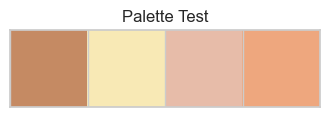

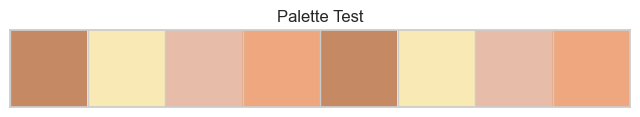

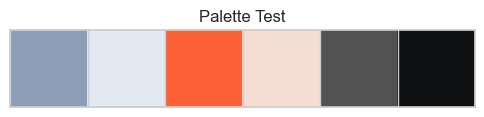

In [41]:
# 팔레트 색상 테스트
from matplotlib.colors import LinearSegmentedColormap
from itertools import cycle

beauty_palette = ['#C58A63', '#F8E9B5', '#E7BCA9', '#EEA77E']
market_palette = ["#003f5c", "#214876", "#4e4c8a", "#7e4a93", "#ae448d", "#d63e7a", "#f1465d", "#fd6036"]
market_palette =  [color for color, _ in zip(cycle(beauty_palette), range(len(market_palette)))]

skin_palette = ['#8C9DB7', '#E3E9F2', '#FD6036','#F6DDD3', '#525252', '#0E1012']
custom_cmap = LinearSegmentedColormap.from_list("custom_palette", market_palette)

sns.palplot(beauty_palette)
plt.title("Palette Test")
plt.show()

sns.palplot(market_palette)
plt.title("Palette Test")
plt.show()

sns.palplot(skin_palette)
plt.title("Palette Test")
plt.show()

> K-beauty 하위 카테고리 및 브랜드 구성 확인

In [42]:
# K-beauty 하위 카테고리 별 개수
ak_category_count = pd.DataFrame(amazon_df.Amazon_Category.value_counts())
ak_category_count.reset_index(inplace=True)
ak_category_count.columns = ['Amazon_Category', 'Count']
print(ak_category_count.head())

# K-beauty 아이템 별 개수
category_count = pd.DataFrame(amazon_df.Sub_Category_Name.value_counts())
category_count.reset_index(inplace=True)
category_count.columns = ['Sub_Category', 'Count']
print(category_count.head())

                   Amazon_Category  Count
0               Skin Care Products  11989
1                           Makeup    755
2  Foot, Hand & Nail Care Products     45
3       Beauty Tools & Accessories      8
            Sub_Category  Count
0          Facial Serums   2816
1      Face Moisturizers   2115
2   Facial Toners & Astr   1654
3           Facial Masks   1498
4          Facial Cleans   1242


In [43]:
# K-beauty 브랜드 별 개수 (상품 수로 추정 또는 상품 수는 직접 사이트 들어가서 눌러보고 ㅎ 컬럼 별로 입력)
amazon_df.brand.unique()

# 브랜드 별 리뷰 개수 (상위 30개) # 상위 30개가 아닌 선택한 브랜드 5개
k_brand_count = pd.DataFrame(amazon_df.brand.value_counts().head(31))
k_brand_count.reset_index(inplace=True)
k_brand_count.columns = ['brand', 'count']
k_brand_count.drop(0, axis=0, inplace=True)
k_brand_count.head()

,brand,count
1,PURITO,2388
2,I'm from,1779
3,Dr.Jart+,1771
4,Beauty of Joseon,1670


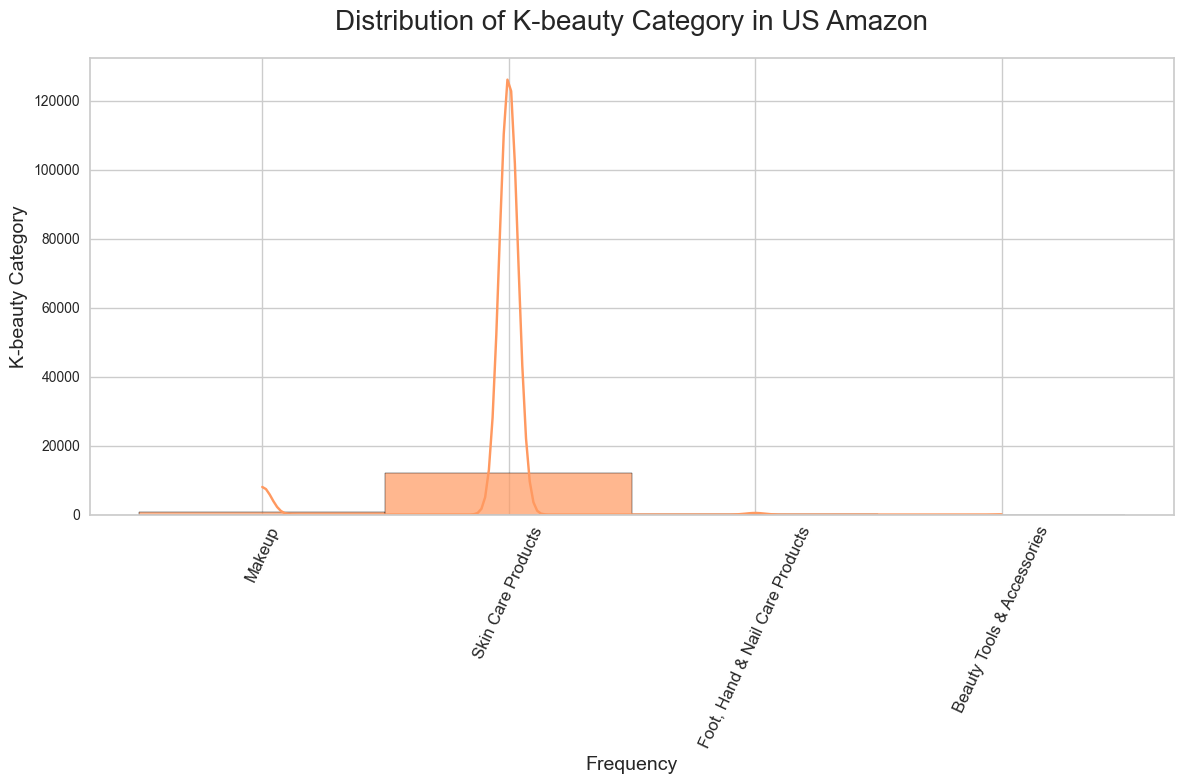

In [44]:
# 카테고리 분포
plt.figure(figsize=(12,8))
sns.histplot(data=amazon_df['Amazon_Category'], bins=31, alpha=0.7, color='#FF9960', kde=True)
plt.title('Distribution of K-beauty Category in US Amazon', fontsize=20, pad=20)

plt.xticks(rotation=65, fontsize=12)
plt.xlabel('Frequency', fontsize=14)
plt.ylabel('K-beauty Category', fontsize=14)

plt.tight_layout()
plt.show()

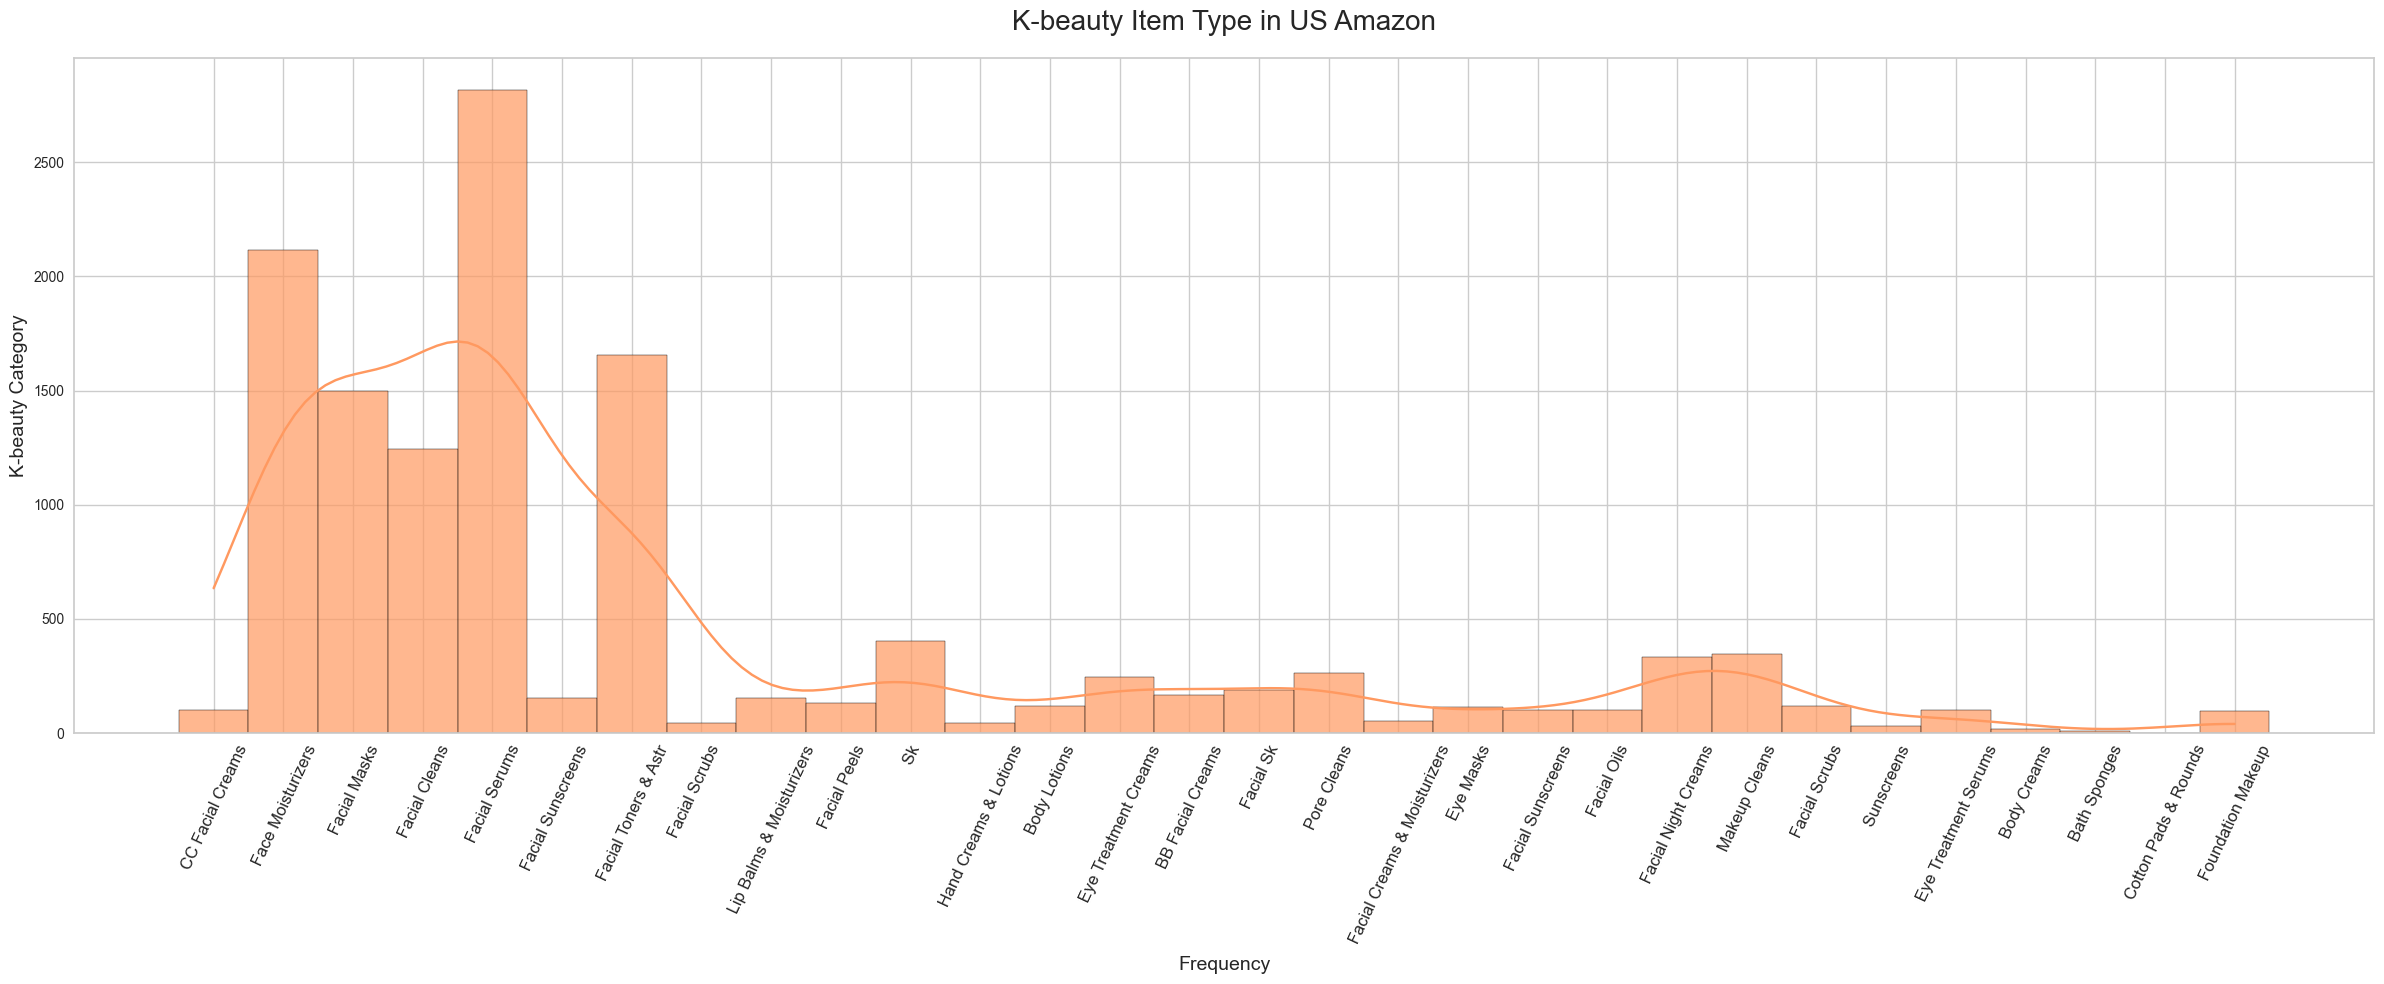

In [45]:
# 제품 유형 분포
plt.figure(figsize=(24,10))
sns.histplot(data=amazon_df['Sub_Category_Name'], bins=31, alpha=0.7, color='#FF9960', kde=True)
plt.title('K-beauty Item Type in US Amazon', fontsize=20, pad=20)

plt.xticks(rotation=65, fontsize=12)
plt.xlabel('Frequency', fontsize=14)
plt.ylabel('K-beauty Category', fontsize=14)

plt.tight_layout()
plt.show()

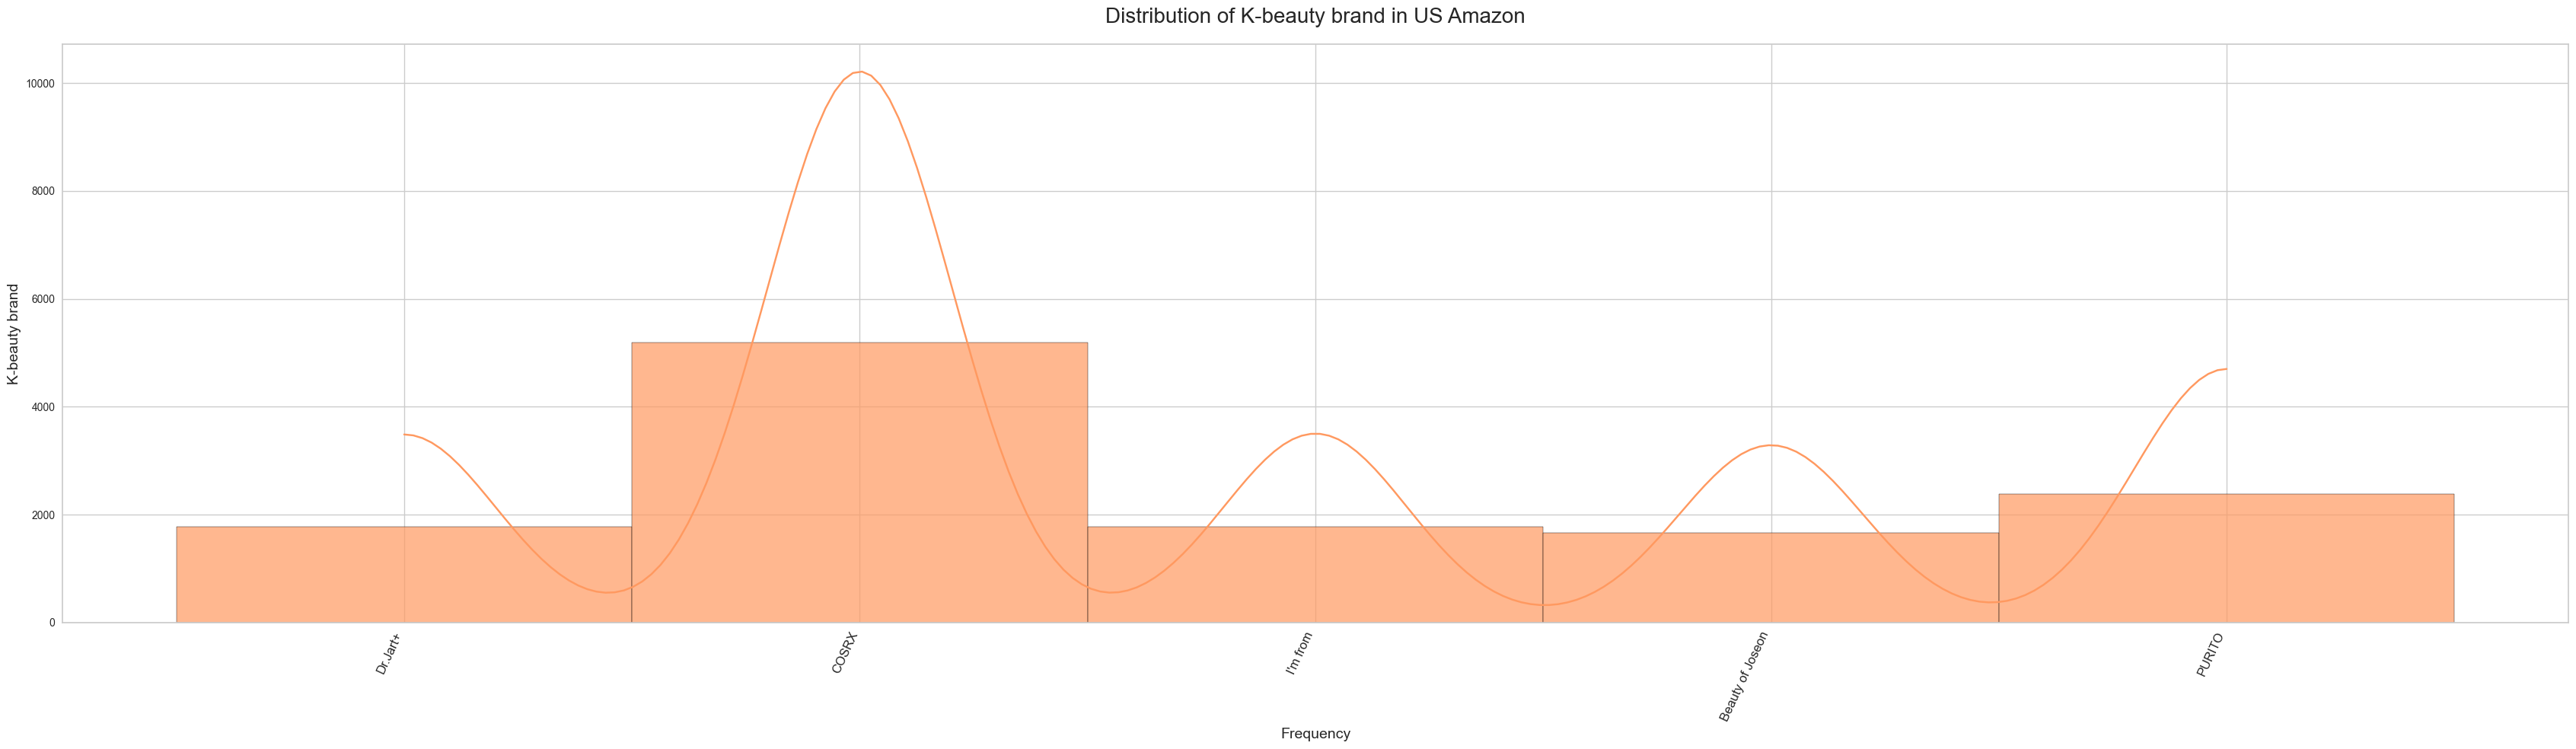

In [46]:
# 브랜드 분포
plt.figure(figsize=(34,10))
sns.histplot(data=amazon_df, x='brand', color='#FF9960', alpha=0.7, kde=True)
plt.title('Distribution of K-beauty brand in US Amazon', fontsize=20, pad=20)

plt.xticks(rotation=65, fontsize=12, ha='right')
plt.xlabel('Frequency', fontsize=14)
plt.ylabel('K-beauty brand', fontsize=14)

plt.tight_layout()
plt.show()

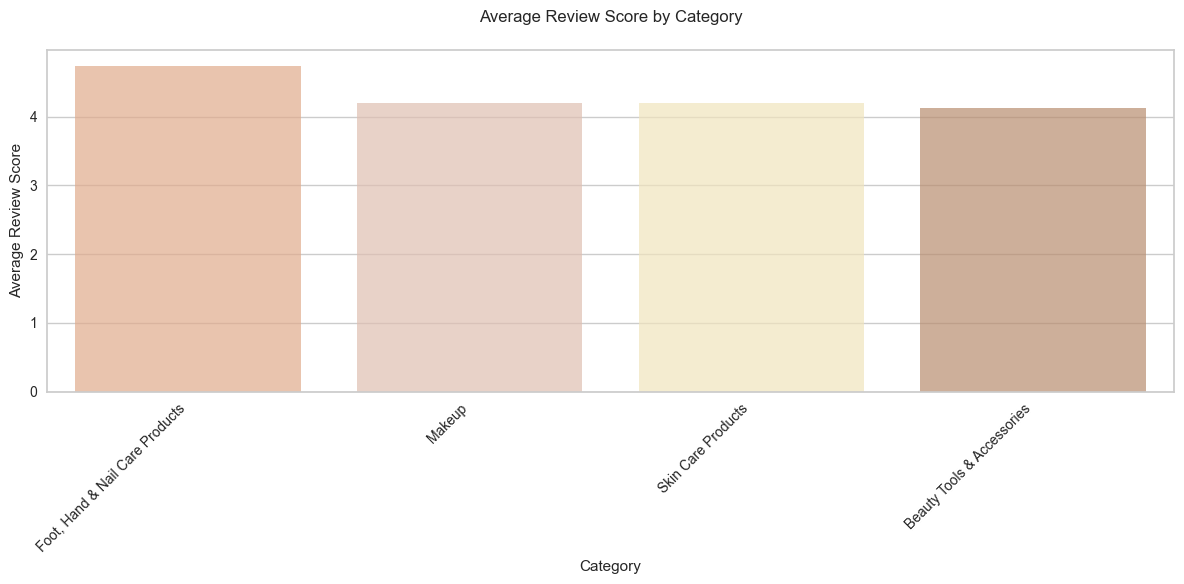

In [47]:
# <카테고리, 제품 유형, 브랜드 별 <-> 리뷰 평점 확인>
# 1. 카테고리별 평균 리뷰 평점
category_mean = pd.pivot_table(amazon_df, index=['Amazon_Category'], values='review_rating',aggfunc='mean')
category_mean = category_mean.reset_index().sort_values(by='review_rating', ascending=False)
category_mean.head(2)

plt.figure(figsize=(12, 6))
sns.barplot(data=category_mean, x='Amazon_Category', y='review_rating', dodge=False, palette=market_palette[-1::-1], alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.title('Average Review Score by Category', pad=20)
plt.ylabel('Average Review Score')
plt.xlabel('Category')
plt.tight_layout()
plt.show()

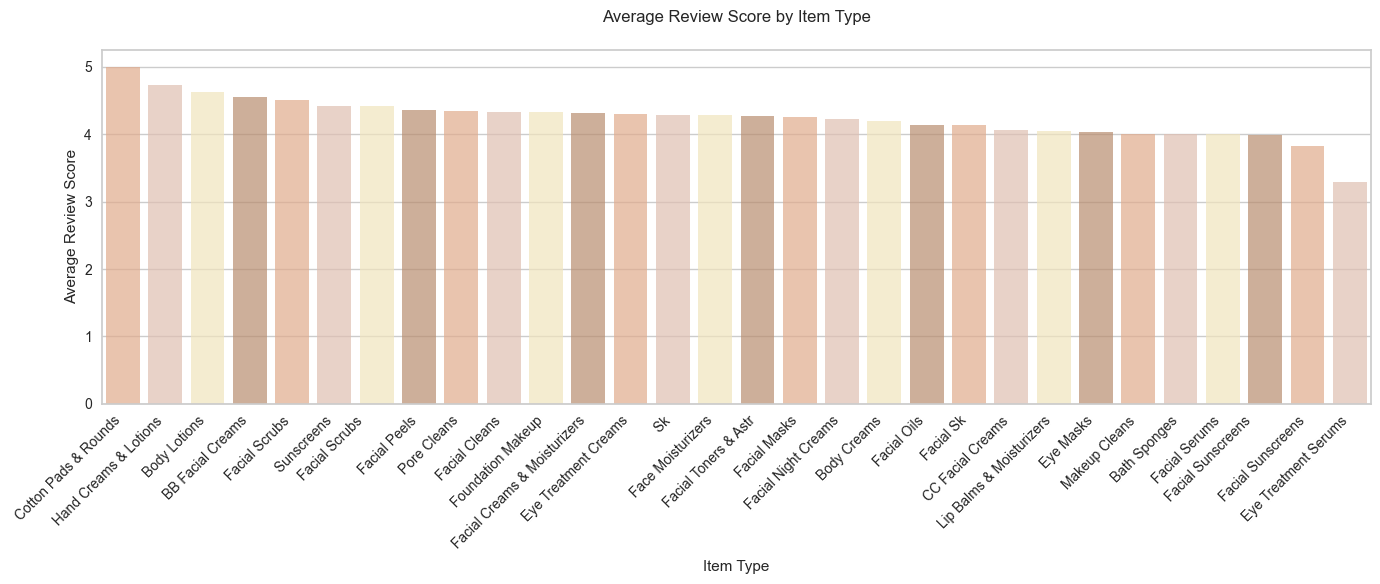

In [48]:
# <카테고리, 제품 유형, 브랜드 별 <-> 리뷰 평점 확인>
# 1-2. 제품 유형 별 평균 리뷰 평점
category_mean = pd.pivot_table(amazon_df, index=['Sub_Category_Name'], values='review_rating',aggfunc='mean')
category_mean = category_mean.reset_index().sort_values(by='review_rating', ascending=False)
category_mean.head(2)

plt.figure(figsize=(14, 6))
sns.barplot(data=category_mean, x='Sub_Category_Name', y='review_rating', dodge=False, palette=market_palette[-1::-1], alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.title('Average Review Score by Item Type', pad=20)
plt.ylabel('Average Review Score')
plt.xlabel('Item Type')
plt.tight_layout()
plt.show()

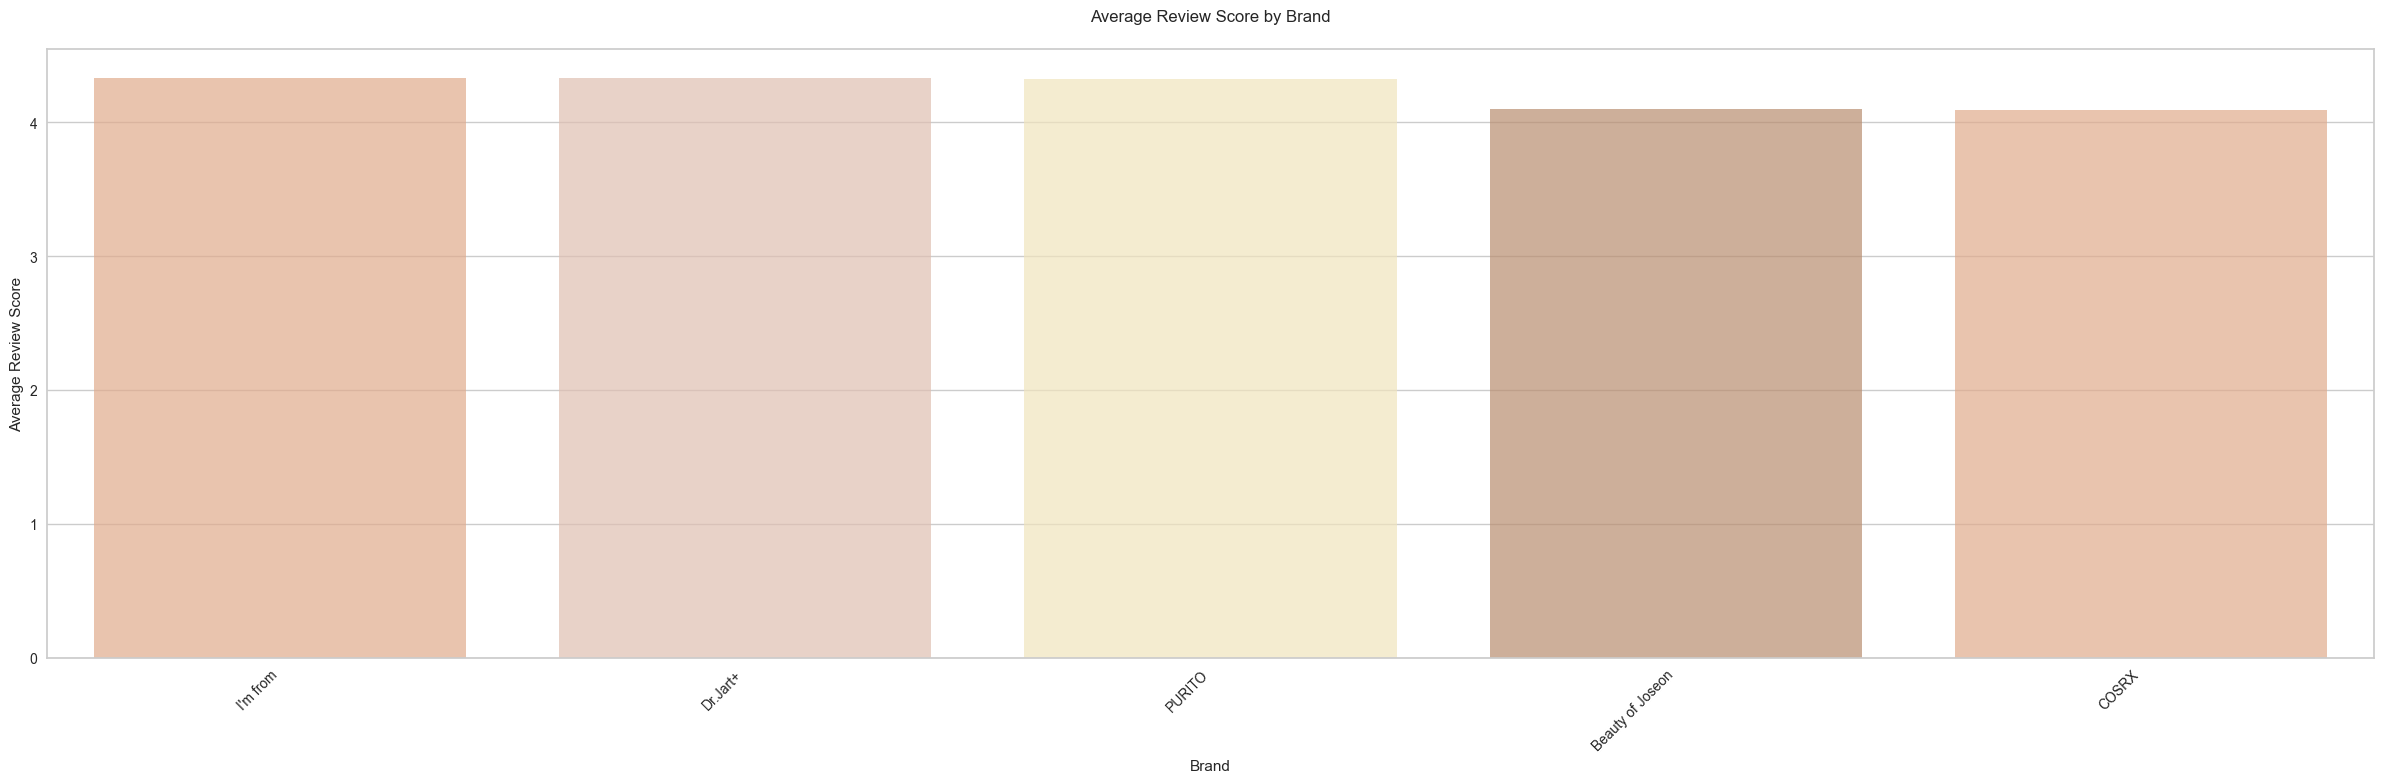

In [49]:
# 2. 브랜드별 평균 리뷰 평점
filtered_df = amazon_df[['brand', 'review_rating']].copy()

filtered_df['review_rating'] = pd.to_numeric(filtered_df['review_rating'], errors='coerce')
filtered_df.dropna(subset=['brand', 'review_rating'], inplace=True)

brand_review_score = pd.pivot_table(
    filtered_df,
    index=['brand'],
    values='review_rating',
    aggfunc='mean'
)
brand_review_score = brand_review_score.reset_index().sort_values(by='review_rating', ascending=False)
brand_review_score.reset_index(inplace=True, drop=True)
brand_review_score[:20]

brand_review_score.head(2)

plt.figure(figsize=(24, 8))
sns.barplot(data=brand_review_score, x='brand', y='review_rating', dodge=False, palette=market_palette[-1::-1], alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.title('Average Review Score by Brand', pad=20)
plt.ylabel('Average Review Score')
plt.xlabel('Brand')
plt.tight_layout()
plt.show()

In [50]:
# # K-beauty 하위 카테고리와 브랜드 별 리뷰 평점 평균 시각화
# import itertools
# plt.close()

# num_bars = 54
# extended_palette = list(itertools.islice(itertools.cycle(market_palette), num_bars))

# fig, axes = plt.subplots(2, 1, figsize=(34, 10), sharex=False)

# # 1. 카테고리별 Sub-Category 평점 평균
# sns.barplot(
#     data=category_mean, 
#     x='Sub_Category_Name', 
#     y='review_rating', 
#     hue='Category_Name', 
#     dodge=False, 
#     palette=extended_palette, 
#     ax=axes[0]
# )
# axes[0].set_title('Average Review Ratings by Sub-Category')
# axes[0].set_ylabel('Average Rating')
# axes[0].set_xlabel('Sub-Category')
# axes[0].tick_params(axis='x', rotation=45)
# axes[0].legend(title='Category Name')

# # 2. 브랜드별 평점 평균
# sns.barplot(
#     data=brand_review_score, 
#     x='brand', 
#     y='review_rating', 
#     palette=extended_palette, 
#     ax=axes[1]
# )
# axes[1].set_title('Average Review Ratings by Brand')
# axes[1].set_ylabel('Average Rating')
# axes[1].set_xlabel('Brand')
# axes[1].tick_params(axis='x', rotation=45)

# plt.tight_layout()
# plt.show()

In [51]:
import plotly.graph_objects as go

df = brand_review_score.head(30)

fig = go.Figure(data=[go.Table(
    header=dict(values=df.columns, fill_color='paleturquoise', align='center'),
    cells=dict(values=[df[col] for col in df.columns], fill_color='lavender', align='center'))
])

fig.update_layout(title='Brand Review Scores')
fig.show()

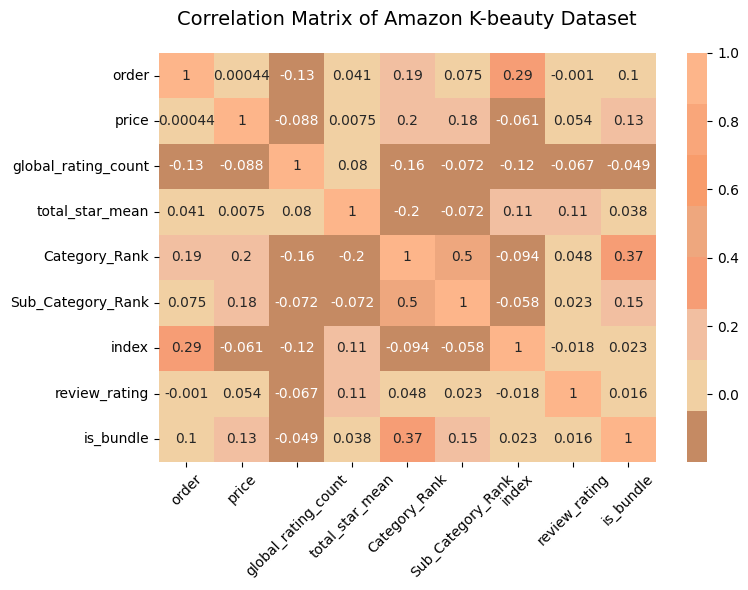

In [52]:
# 전반적인 상관관계
ordinal_palette = [
    '#C58A63', 
    '#F1D0A3', 
    '#F2BFA1',  
    '#F69D75',  
    '#EEA77E',  
    '#F89C6B',  
    '#F9A67A',  
    '#FDB58A'
]

plt.close()

sns.reset_defaults()
plt.rcdefaults()
plt.style.use('default')
plt.figure(figsize=(8,6))

sample_data = amazon_df.select_dtypes(include=["number"])

#compute correlation
corr_matrix = sample_data.corr()
corr_matrix

#annot=True return the correlation values
sns.heatmap(corr_matrix, cmap=ordinal_palette, annot=True)
plt.xticks(rotation=45)
plt.title('Correlation Matrix of Amazon K-beauty Dataset', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

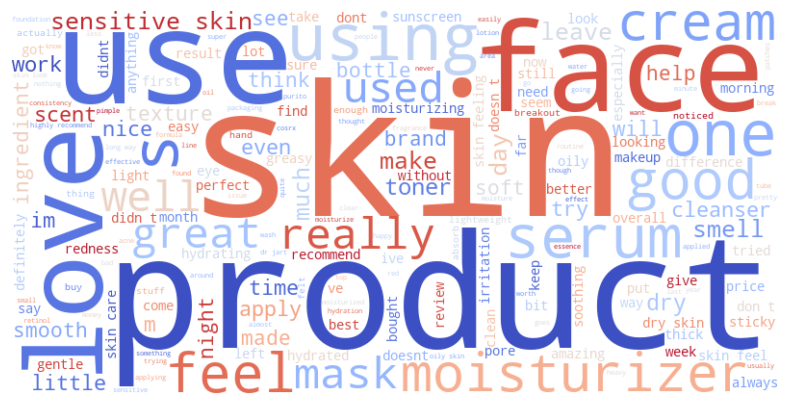

In [53]:
from wordcloud import WordCloud

# 전처리된 아마존 모든 리뷰 워드 클라우드
wordcloud = WordCloud(width=800, height=400, 
                      background_color='white', colormap='coolwarm').generate(' '.join(amazon_df['cleaned_review'].dropna()))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
# plt.title("Word Cloud - Item Review")
plt.show()

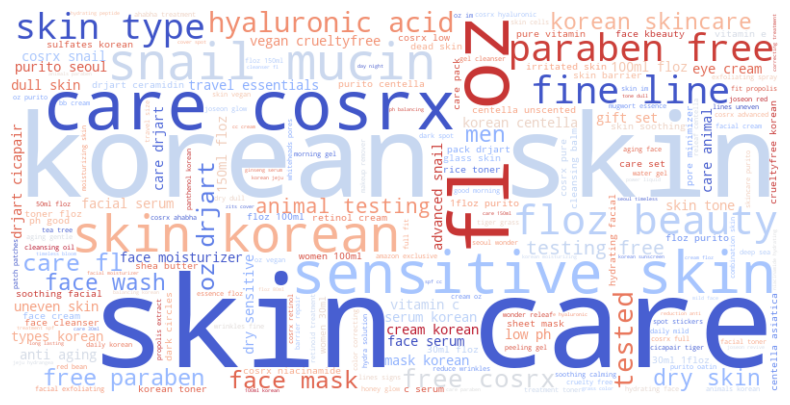

In [54]:
# 전처리된 상품 제목 (아이템 이름) 워드 클라우드
wordcloud = WordCloud(width=800, height=400, 
                      background_color='white', colormap='coolwarm').generate(' '.join(amazon_df['cleaned_title'].dropna()))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
# plt.title("Word Cloud - Item Title")
plt.show()

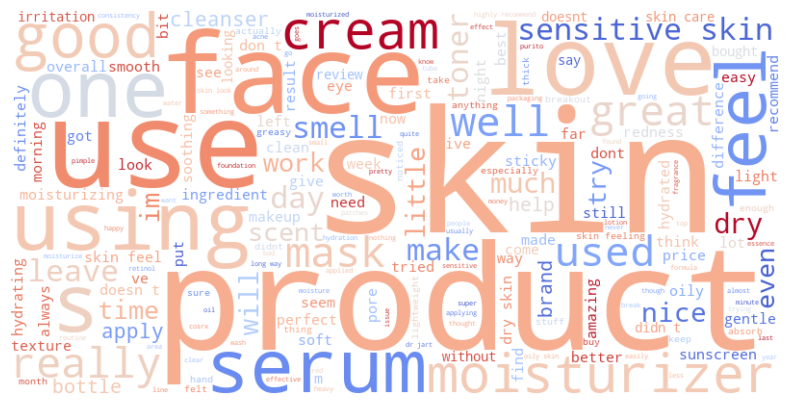

In [55]:
# top 30 브랜드 (평점 기준도 확인 필요) - 리뷰 내용 워드 클라우드 # 선정 브랜드 5개
top30_brand_list = brand_review_score['brand'].head(30).tolist()
query_cond = amazon_df['brand'].isin(top30_brand_list)
top_df = amazon_df[query_cond]

wordcloud = WordCloud(width=800, height=400, 
                      background_color='white', colormap='coolwarm').generate(' '.join(top_df['cleaned_review'].dropna()))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
# plt.title("Word Cloud - Item Title")
plt.show()

### ◼ Skinsort

In [56]:
import plotly.express as px
import plotly.io as pio

df = skinsort_copy

country_dist = df['country'].value_counts().reset_index()
country_dist.columns = ['Country', 'Count']

fig = px.pie(country_dist[:15], values='Count', names='Country', title=f"Country Distribution for Skinsort Brand Data")
fig.update_traces(hole=.3)
# imgname = "skinsort_country_distribution.png"
# fig.write_image(DATA_PATH+imgname)
fig.show()

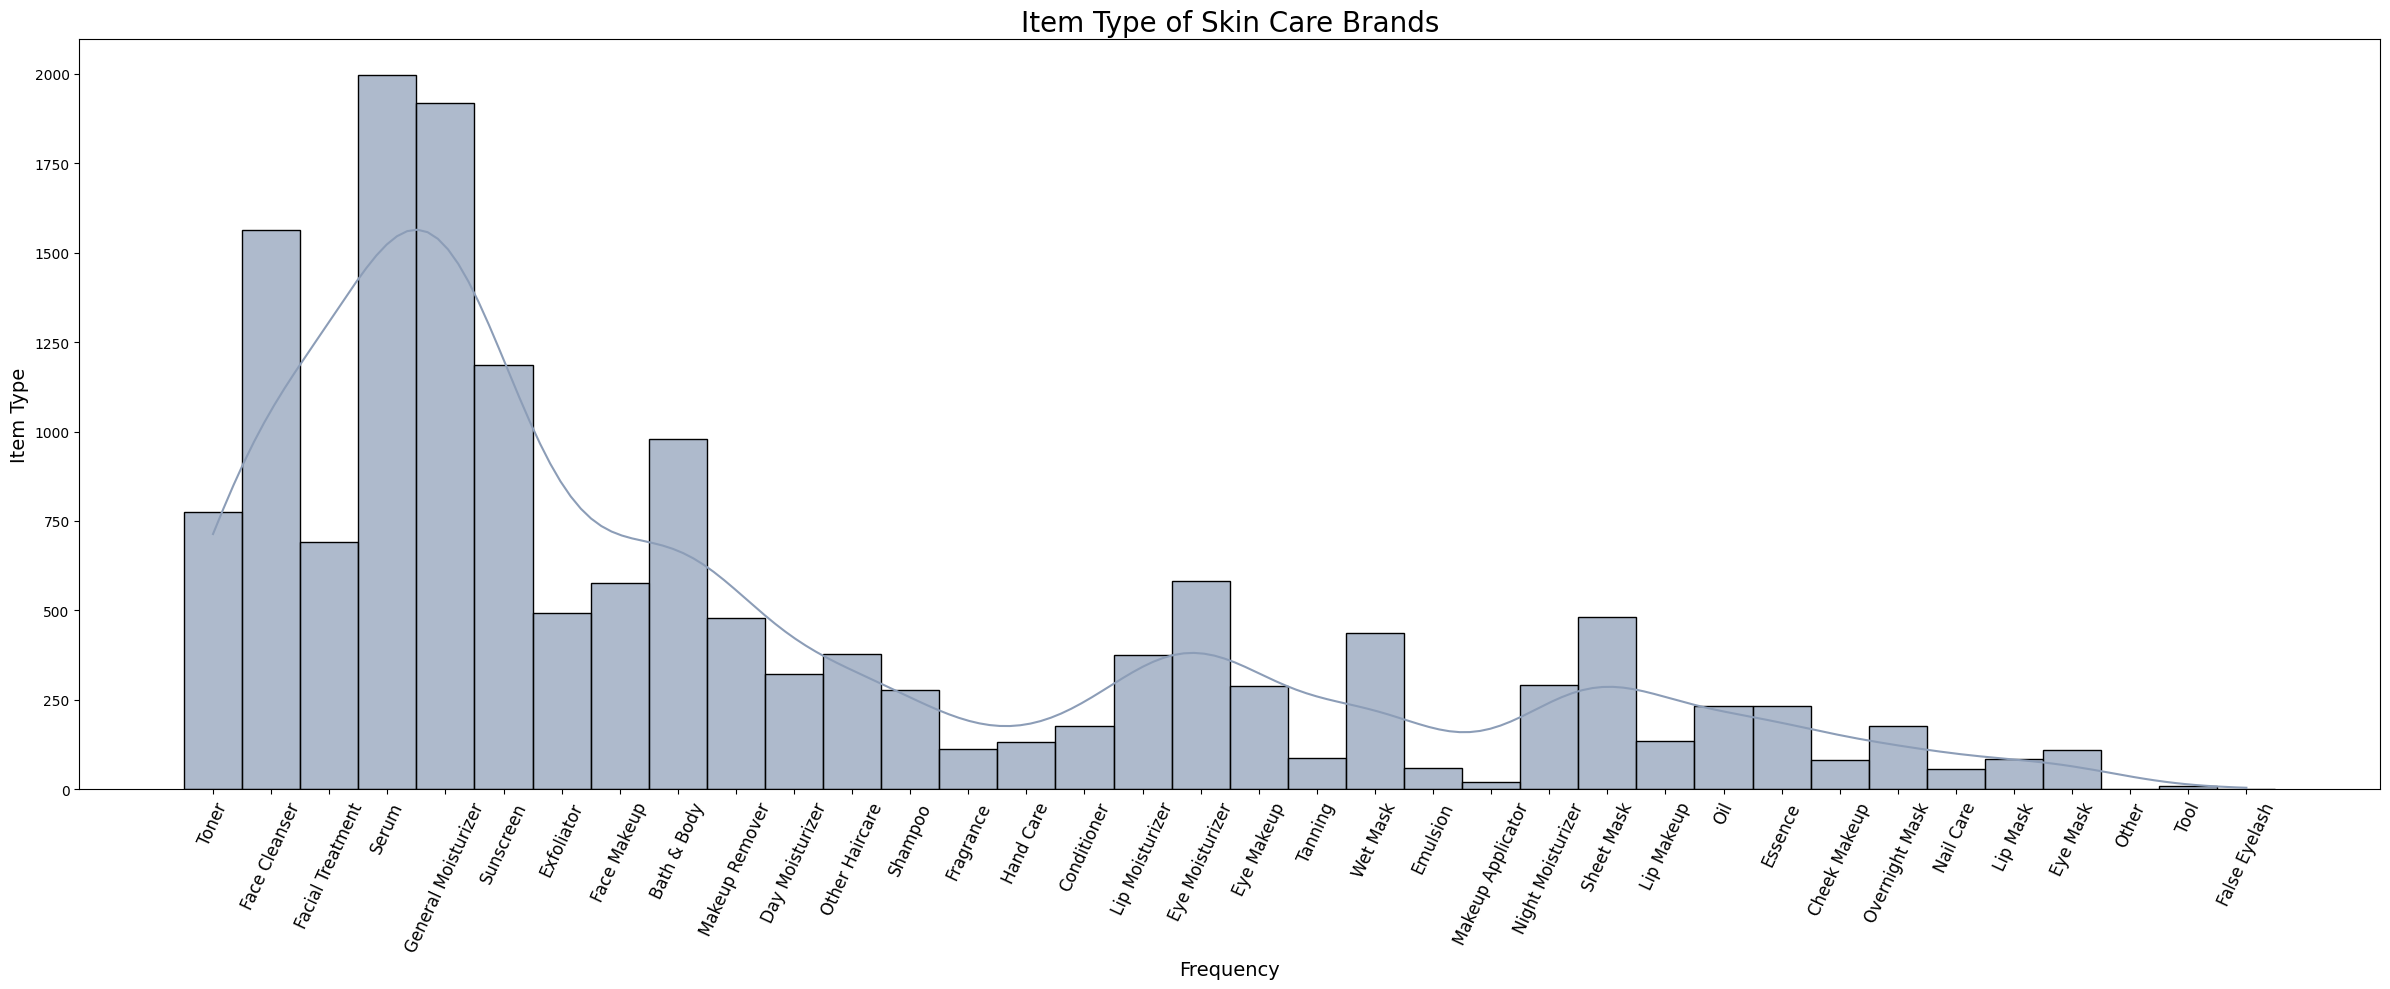

In [57]:
# 카테고리 분포
plt.figure(figsize=(24,10))
sns.histplot(data=skinsort_copy['type'], bins=31, alpha=0.7, color='#8C9DB7', kde=True)
plt.title('Item Type of Skin Care Brands', fontsize=20)

plt.xticks(rotation=65, fontsize=12)
plt.xlabel('Frequency', fontsize=14)
plt.ylabel('Item Type', fontsize=14)

plt.tight_layout()
plt.show()

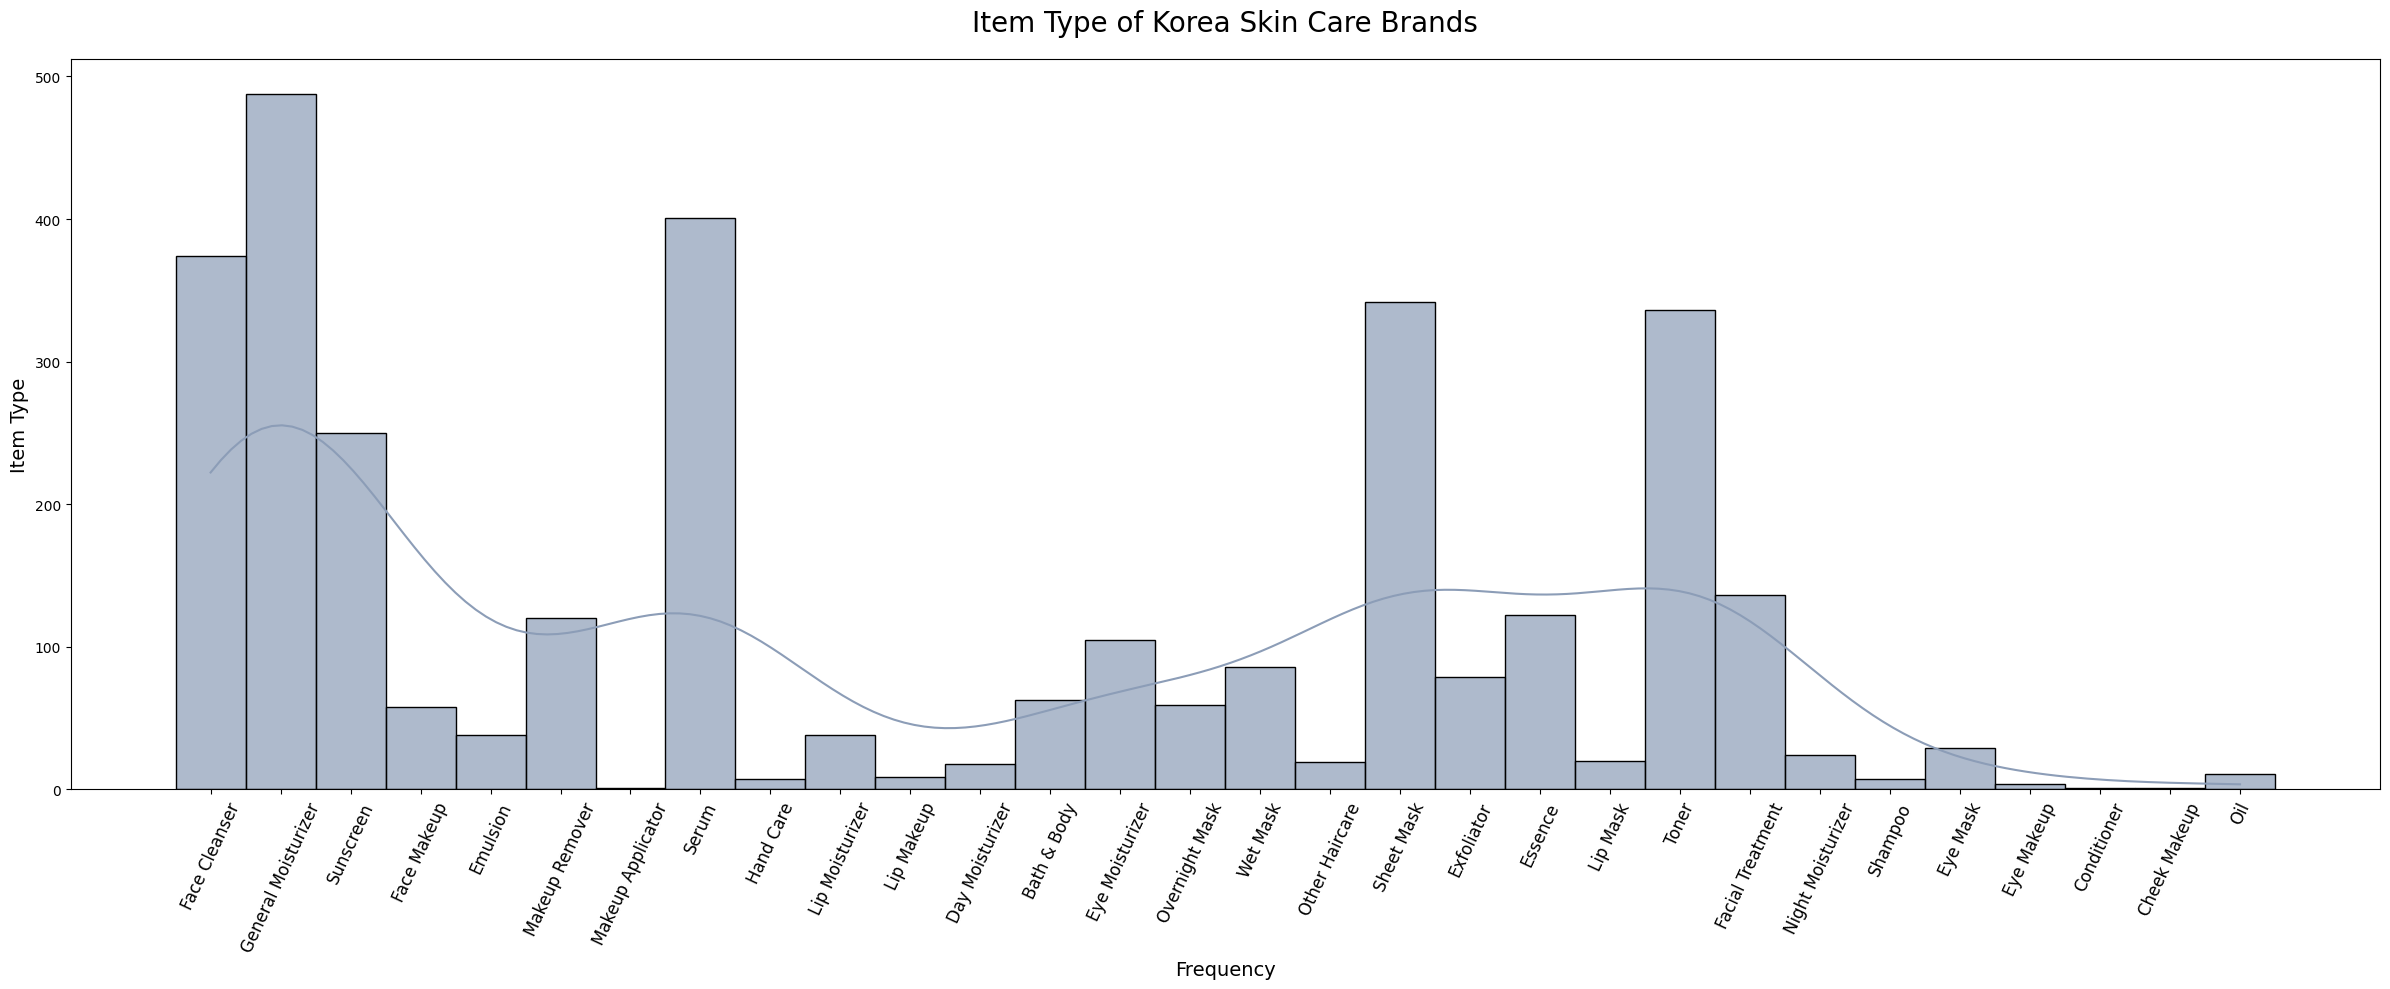

In [58]:
# 한국 스킨케어 브랜드들의 제품 타입 분포
# skincare 데이터셋 활용용
query_cond = "country == 'South Korea'"
k_skin_brand = skinsort_copy.query(query_cond).reset_index()
k_skin_brand.drop(columns='index', inplace=True)
k_skin_brand.head(2)

plt.figure(figsize=(24,10))

sns.histplot(data=k_skin_brand['type'], bins=31, alpha=0.7, color='#8C9DB7', kde=True)
plt.title('Item Type of Korea Skin Care Brands', fontsize=20, pad=20)

plt.xticks(rotation=65, fontsize=12)
plt.xlabel('Frequency', fontsize=14)
plt.ylabel('Item Type', fontsize=14)

plt.tight_layout()
plt.show()

> Skinsort 한국 스킨케어 브랜드의 제품 유형 분포
- 일반적으로 알고 있는 것과 비슷함. general moisture, serum, sheet mask, toner 등 기초 제품들과 마스크팩이 많음 !

In [59]:
k_skin_brand.head(2)

,level_0,brand,name,type,country,ingridients,afterUse,cleaned_ingridients,cleaned_afterUse,tokenized_ingridients,tokenized_afterUse,stemmed_ingridients,stemmed_afterUse,stpw_processed_ingridients,stpw_processed_afterUse
0,4,COSRX,Low pH Good Morning Gel Cleanser,Face Cleanser,South Korea,"Water,Cocamidopropyl Betaine,Sodium Lauroyl Me...","Good For Oily Skin,Reduces Irritation,Reduces ...",watercocamidopropyl betainesodium lauroyl meth...,good for oily skinreduces irritationreduces la...,"[watercocamidopropyl, betainesodium, lauroyl, ...","[good, for, oily, skinreduces, irritationreduc...","[watercocamidopropyl, betainesodium, lauroyl, ...","[good, for, oili, skinreduc, irritationreduc, ...","[watercocamidopropyl, betainesodium, lauroyl, ...","[good, oily, skinreduces, irritationreduces, l..."
1,7,COSRX,Advanced Snail 92 All In One Cream,General Moisturizer,South Korea,"Snail Secretion Filtrate,Betaine,Caprylic/Capr...","Redness Reducing,Reduces Irritation,May Worsen...",snail secretion filtratebetainecapryliccapric ...,redness reducingreduces irritationmay worsen o...,"[snail, secretion, filtratebetainecapryliccapr...","[redness, reducingreduces, irritationmay, wors...","[snail, secret, filtratebetainecapryliccapr, t...","[red, reducingreduc, irritationmay, worsen, oi...","[snail, secretion, filtratebetainecapryliccapr...","[redness, reducingreduces, irritationmay, wors..."


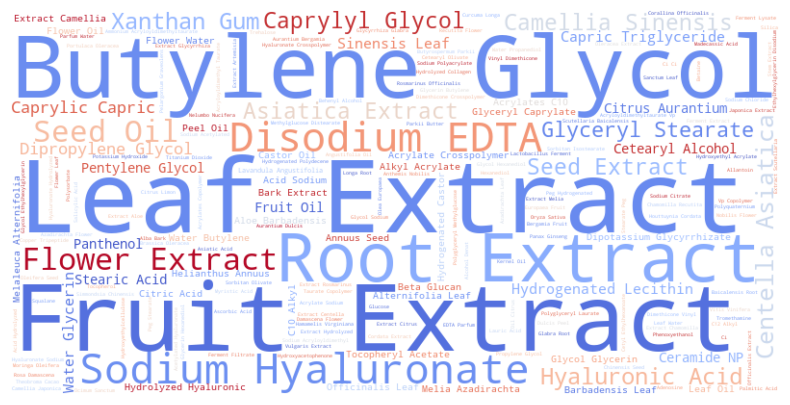

In [60]:
# 한국 스킨케어 브랜드 성분
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400, 
                      background_color='white', colormap='coolwarm').generate(' '.join(k_skin_brand['ingridients'].dropna()))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
# plt.title("Word Cloud - Item Review")
plt.show()

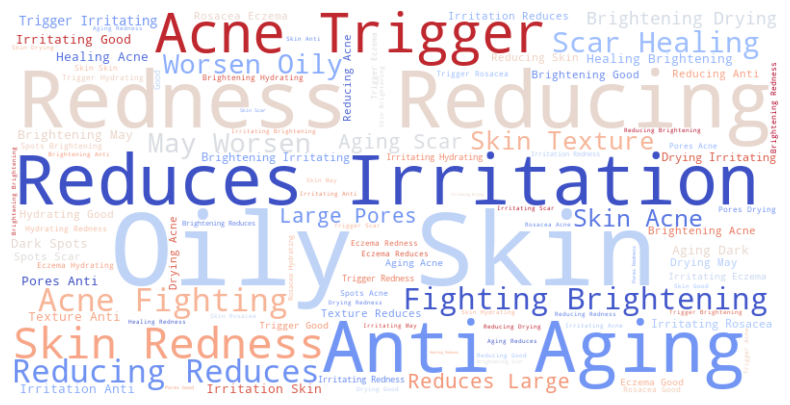

In [61]:
# 한국 스킨케어 브랜드 - 사용후
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400, 
                      background_color='white', colormap='coolwarm').generate(' '.join(k_skin_brand['afterUse'].dropna()))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
# plt.title("Word Cloud - Item Review")
plt.show()

> 사용 후 반응
- 피부 타입 개인 차에 따른 반응들이 여기도 많음. 더 기름이 심해졌다, 건조하다 등
- 간지러움, 붉어짐 등 -> 개인적인 생각이지만 너무 특이한 성분? 약초나 시카 성분 등 자연성분을 강조한다고 너무 특이한 게 들어가면 개인 차를 많이 타는 것 같음

# PART 3: Data Analysis

### ◼ Amazon

#### Sentiment Analysis

In [62]:
k_skin_brand.dropna(subset=['ingridients'], inplace=True)
k_skin_brand['splitted_ingridients'] = k_skin_brand['ingridients'].apply(lambda x: str(x).split(',') if pd.notna(x) else [])

print(k_skin_brand['splitted_ingridients'].head())

k_skin_brand.dropna(subset=['afterUse'], inplace=True)
k_skin_brand['splitted_afterUse'] = k_skin_brand['afterUse'].apply(lambda x: str(x).split(',') if pd.notna(x) else [])

print(k_skin_brand['splitted_afterUse'].head())

0    [Water, Cocamidopropyl Betaine, Sodium Lauroyl...
1    [Snail Secretion Filtrate, Betaine, Caprylic/C...
2    [Water, Oryza Sativa Extract 30%, Dibutyl Adip...
3    [Water, Octocrylene, Citrullus Lanatus Fruit E...
4    [Water, Cyclopentasiloxane, Ethylhexyl Methoxy...
Name: splitted_ingridients, dtype: object
0    [Good For Oily Skin, Reduces Irritation, Reduc...
1    [Redness Reducing, Reduces Irritation, May Wor...
2    [Good For Oily Skin, Redness Reducing, Acne Fi...
3    [Drying, May Worsen Oily Skin, Acne Trigger, I...
4    [Good For Oily Skin, Redness Reducing, Brighte...
Name: splitted_afterUse, dtype: object


In [63]:
# from sklearn.feature_extraction.text import TfidfVectorizer

# # Ensure columns are lists of strings
# column1_texts = [' '.join(ingredients) for ingredients in k_skin_brand.splitted_ingridients]
# column2_texts = [' '.join(after_use) for after_use in k_skin_brand.splitted_afterUse]

# # Apply TfidfVectorizer
# vectorizer = TfidfVectorizer()
# column1_vectors = vectorizer.fit_transform(column1_texts)
# column2_vectors = vectorizer.transform(column2_texts)

# import numpy as np
# from scipy.stats import pearsonr

# correlations = []
# for i in range(column1_vectors.shape[1]):
#     try:
#         # Calculate Pearson correlation for each feature
#         corr, _ = pearsonr(column1_vectors[:, i].toarray().flatten(), 
#                            column2_vectors[:, i].toarray().flatten())
#         correlations.append(corr)
#     except Exception as e:
#         # Handle cases where Pearson correlation fails
#         correlations.append(np.nan)

# # Visualization
# import matplotlib.pyplot as plt
# import seaborn as sns

# plt.figure(figsize=(12, 8))
# sns.heatmap(np.array(correlations).reshape(-1, 1), 
#             cmap='coolwarm', center=0, cbar_kws={'label': 'Correlation'})
# plt.title('Element-wise Correlation between Two Text Columns')
# plt.show()

In [64]:
# 감성 분석을 위한 코드
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Create an instance of SentimentIntensityAnalyzer, which is part of the VADER sentiment analysis tool.
analyzer = SentimentIntensityAnalyzer()

# Function to apply VADER sentiment analysis to each review.
# The function takes in a 'review' (text) and returns the polarity scores, which include
# 'compound', 'positive', 'negative', and 'neutral' sentiment values.
def get_sentiment(review):
    return analyzer.polarity_scores(review)

# Apply the 'get_sentiment' function to each entry in the 'Cleaned_Review' column.
# Store the resulting sentiment scores (dictionary) in a new column 'vader_scores'.
amazon_df['cleaned_review'] = amazon_df['cleaned_review'].astype(str)
amazon_df['vader_scores'] = amazon_df['cleaned_review'].apply(get_sentiment)

k_skin_brand['afterUse'] = k_skin_brand['afterUse'].astype(str)
k_skin_brand['vader_scores'] = k_skin_brand['afterUse'].apply(get_sentiment)

# Extract the 'compound' score from the 'vader_scores' dictionary for each review.
# The 'compound' score is a normalized score ranging from -1 (most negative) to +1 (most positive),
# summarizing the overall sentiment of the text.
amazon_df['compound'] = amazon_df['vader_scores'].apply(lambda score_dict: score_dict['compound'])
k_skin_brand['compound'] = k_skin_brand['vader_scores'].apply(lambda score_dict: score_dict['compound'])

# Function to classify the sentiment based on the 'compound' score.
# Scores >= 0.05 are classified as 'Positive', <= -0.05 as 'Negative', and anything in between as 'Neutral'.
def classify_sentiment(compound_score):
    if compound_score >= 0.05:
        return 'Positive'
    elif compound_score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Apply the 'classify_sentiment' function to the 'compound' score to get the overall sentiment
# classification (Positive, Negative, or Neutral) for each review.
amazon_df['sentiment'] = amazon_df['compound'].apply(classify_sentiment)
k_skin_brand['sentiment'] = k_skin_brand['compound'].apply(classify_sentiment)

# Display the first few rows of the DataFrame, showing the cleaned review text,
# the 'compound' sentiment score, and the classified 'sentiment'.
print(amazon_df[['cleaned_review', 'compound', 'sentiment']].head(2))

                                      cleaned_review  compound sentiment
0  not as good as people hype it up to be i’ll us...   -0.5428  Negative
1  had to use this for a bit to give it a review ...    0.5423  Positive


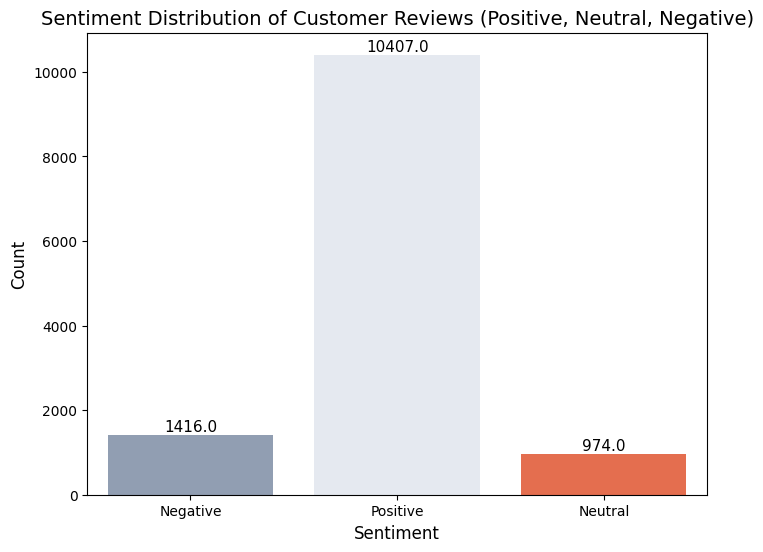

In [65]:
# 아마존
# Assuming df is already loaded and contains the 'sentiment' column
plt.figure(figsize=(8, 6))

# Count plot with a specific color palette
sns.countplot(data=amazon_df, x='sentiment', palette=skin_palette)

# Add title and axis labels with adjusted font sizes
plt.title('Sentiment Distribution of Customer Reviews (Positive, Neutral, Negative)', fontsize=14)
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Adding data labels on top of the bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2, p.get_height()), 
                       ha='center', va='bottom', fontsize=11)

# Display the plot
plt.show()

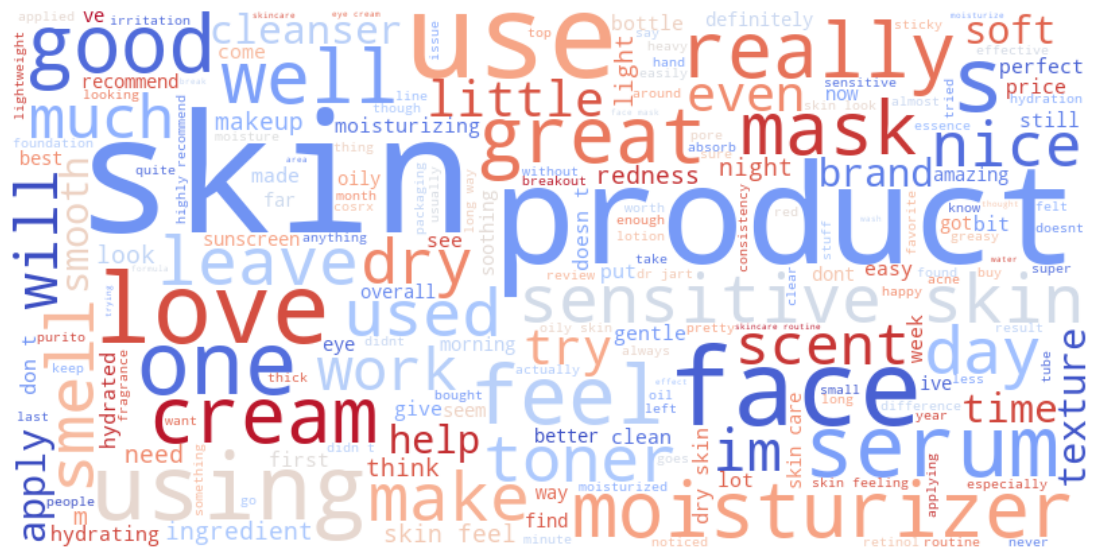

In [66]:
# 긍정적 리뷰 내용 - 워드 클라우드
query_cond = 'sentiment == "Positive"'
pos_df = amazon_df.query(query_cond)
pos_df.reset_index(drop=True, inplace=True)

wordcloud = WordCloud(width=800, height=400, 
                      background_color='white', colormap='coolwarm').generate(' '.join(pos_df['cleaned_review'].dropna()))
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
# plt.title("Word Cloud - Item Title")
plt.show()

> 긍정 리뷰
- 수분 : hydration, hydrated, moisturing, moisture 
- 카테고리 : skin-care, make-up (카테고리인지, 메이크업할 때 잘 먹는다는 건지는 원본을 봐야알듯)
            skin, skin-care, skincare routine 등이 많음
- 아이템 : oil, serum, cleanser, toner, cream
- 시간 : morning, night ..
    
    - 스킨케어 루틴 중에 일상적으로 이용, 수분감 등 기능성에 긍정적 반응이 주로 (현재 샘플 데이터 기준)
    현재, K-beauty 의 경우 Skin care 쪽으로 미국에서 반응이 좋은데 이 부분과 일치하는 리뷰 내용임.

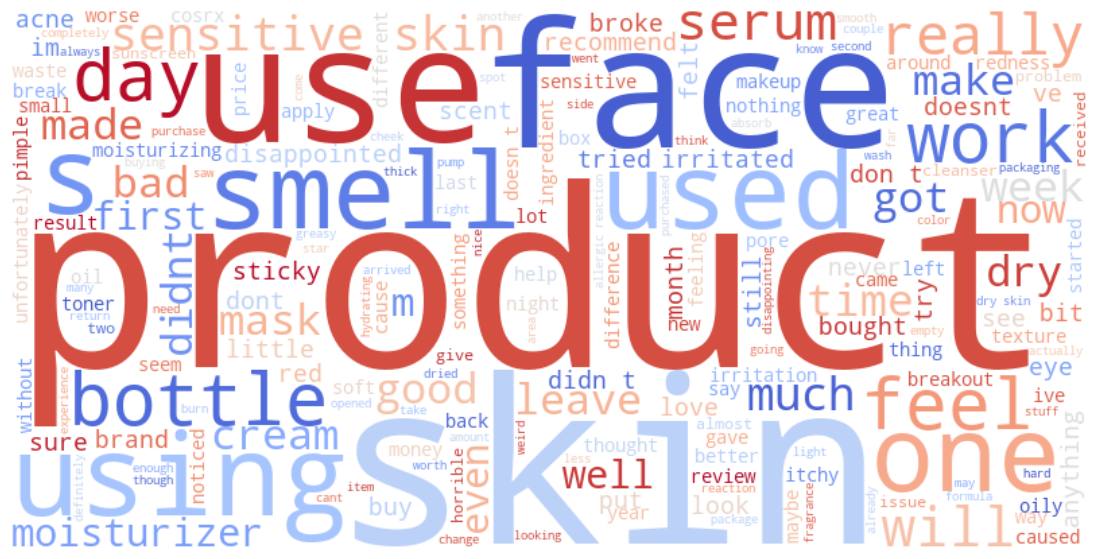

In [67]:
# 부정정적 리뷰 내용 - 워드 클라우드
query_cond = 'sentiment == "Negative"'
neg_df = amazon_df.query(query_cond)
neg_df.reset_index(drop=True, inplace=True)

wordcloud = WordCloud(width=800, height=400, 
                      background_color='white', colormap='coolwarm').generate(' '.join(neg_df['cleaned_review'].dropna()))
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
# plt.title("Word Cloud - Item Title")
plt.show()

> 부정 리뷰
- dry <-> sticky, expected (기대치에 떨어진듯), money (돈이 아깝다는 건지, 비싸다는 건지 리뷰 원본 봐야됨), waste, damaged (제품 패키지가 손상? 본인의 피부가 손상?), horrible..

    - 건조하다 <-> 끈적거린다 : 이거는 고객 피부 타입별로 맞춤형 필요해보임
        waste, damaged, horrible 등 최악의 평가를 받은 리뷰는 내용 확인해볼 필요 있어보임.

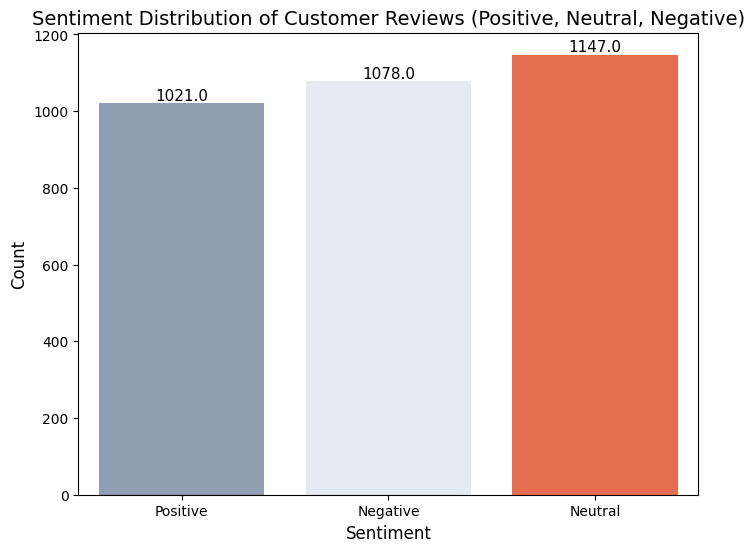

In [68]:
# 스킨쏘트
# Assuming df is already loaded and contains the 'sentiment' column
plt.figure(figsize=(8, 6))

# Count plot with a specific color palette
sns.countplot(data=k_skin_brand, x='sentiment', palette=skin_palette)

# Add title and axis labels with adjusted font sizes
plt.title('Sentiment Distribution of Customer Reviews (Positive, Neutral, Negative)', fontsize=14)
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Adding data labels on top of the bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2, p.get_height()), 
                       ha='center', va='bottom', fontsize=11)

# Display the plot
plt.show()

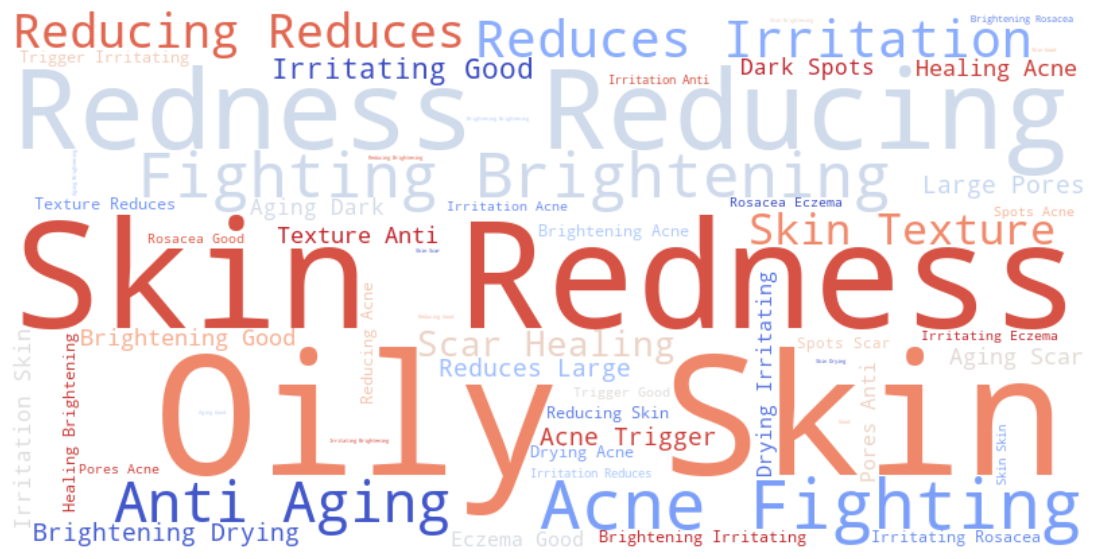

In [69]:
# 긍정적 리뷰 내용 - 워드 클라우드
query_cond = 'sentiment == "Positive"'
pos_df = k_skin_brand.query(query_cond)
pos_df.reset_index(drop=True, inplace=True)

wordcloud = WordCloud(width=800, height=400, 
                      background_color='white', colormap='coolwarm').generate(' '.join(pos_df['afterUse'].dropna()))
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
# plt.title("Word Cloud - Item Title")
plt.show()

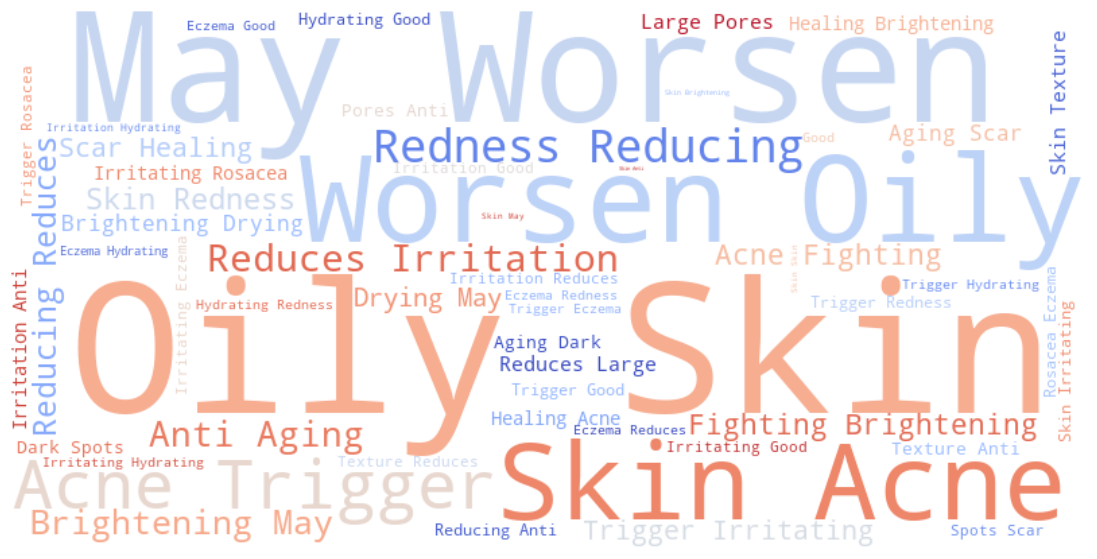

In [70]:
# 부정적 리뷰 내용 - 워드 클라우드
query_cond = 'sentiment == "Negative"'
pos_df = k_skin_brand.query(query_cond)
pos_df.reset_index(drop=True, inplace=True)

wordcloud = WordCloud(width=800, height=400, 
                      background_color='white', colormap='coolwarm').generate(' '.join(pos_df['afterUse'].dropna()))
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
# plt.title("Word Cloud - Item Title")
plt.show()

#### Topic Modeling

https://towardsdatascience.com/end-to-end-topic-modeling-in-python-latent-dirichlet-allocation-lda-35ce4ed6b3e0

> 토픽 모델링을 저희가 가진 컬럼 별로 더 상세하게 진행해해보면, 의미있는 주제 별로 정리해볼 수 있을 것 같습니다.
- 현재 아래 코드 적용된 예시) 아마존 데이터의 리뷰 데이터
- (추가 아이디어) 
 - skinsort 에 afterUse 컬럼 (사용효과) : 수분있는, 보습잘되는, 자극없는, 트러블안생기는 .. 등
 - 아마존이나 스킨쏘트 데이터에 성분 컬럼: 성분들 토픽 별로 묶음
 - 피부 타입에 대한 게 있으면 또 좋을 것 같음: ?

In [71]:
# 내용 추가된 부분!
# 어떻게 활용할 수 있을지 생각해보기!

In [72]:
# Prepare data for LDA Analysis
import gensim
from gensim.utils import simple_preprocess

stop_words = stopwords.words('english')
stop_words.extend(['from', 'subject', 're', 'edu', 'use'])

def sent_to_words(sentences):
    for sentence in sentences:
        # deacc=True removes punctuations
        yield(gensim.utils.simple_preprocess(str(sentence), deacc=True))
        
def remove_stopwords(texts):
    return [[word for word in simple_preprocess(str(doc)) 
             if word not in stop_words] for doc in texts]
    
data = amazon_df.stpw_processed_review.tolist()
data_words = list(sent_to_words(data))
# remove stop words
data_words = remove_stopwords(data_words)
print(data_words[:1][0][:30])

['good', 'people', 'hype', 'gone', 'plan', 'ever', 'reorder']


In [73]:
import gensim.corpora as corpora
# Create Dictionary
id2word = corpora.Dictionary(data_words)
# Create Corpus
texts = data_words
# Term Document Frequency
corpus = [id2word.doc2bow(text) for text in texts]
# View
print(corpus[:1][0][:30])

[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1)]


In [74]:
# LDA model training
from pprint import pprint
# number of topics
num_topics = 10
# Build LDA model
lda_model = gensim.models.LdaMulticore(corpus=corpus,
                                       id2word=id2word,
                                       num_topics=num_topics)
# Print the Keyword in the 10 topics
pprint(lda_model.print_topics())
doc_lda = lda_model[corpus]

[(0,
  '0.018*"skin" + 0.016*"product" + 0.011*"face" + 0.007*"serum" + '
  '0.007*"really" + 0.007*"dry" + 0.006*"like" + 0.006*"great" + 0.006*"well" '
  '+ 0.005*"little"'),
 (1,
  '0.037*"skin" + 0.022*"face" + 0.020*"like" + 0.014*"really" + '
  '0.012*"product" + 0.011*"feel" + 0.009*"dry" + 0.008*"great" + 0.008*"good" '
  '+ 0.007*"using"'),
 (2,
  '0.035*"skin" + 0.016*"product" + 0.011*"face" + 0.009*"using" + '
  '0.008*"would" + 0.008*"like" + 0.008*"one" + 0.006*"products" + '
  '0.006*"really" + 0.006*"cream"'),
 (3,
  '0.039*"skin" + 0.021*"like" + 0.013*"face" + 0.009*"great" + 0.008*"good" + '
  '0.008*"product" + 0.008*"love" + 0.008*"one" + 0.007*"using" + '
  '0.006*"mask"'),
 (4,
  '0.029*"skin" + 0.013*"like" + 0.010*"products" + 0.010*"product" + '
  '0.009*"great" + 0.008*"face" + 0.007*"well" + 0.007*"feel" + '
  '0.007*"moisturizer" + 0.007*"serum"'),
 (5,
  '0.033*"skin" + 0.018*"like" + 0.017*"love" + 0.013*"product" + 0.013*"face" '
  '+ 0.009*"really" + 0.

In [75]:
import os
import pyLDAvis.gensim
import pickle 
import pyLDAvis
# Visualize the topics
pyLDAvis.enable_notebook()
LDAvis_data_filepath = os.path.join('./results/ldavis_prepared_'+str(num_topics))

# Create directory if it does not exist
if not os.path.exists('./results'):
    os.makedirs('./results')

# # this is a bit time consuming - make the if statement True
# # if you want to execute visualization prep yourself
if 1 == 1:
    LDAvis_prepared = pyLDAvis.gensim.prepare(lda_model, corpus, id2word)
    with open(LDAvis_data_filepath, 'wb') as f:
        pickle.dump(LDAvis_prepared, f)
# load the pre-prepared pyLDAvis data from disk
with open(LDAvis_data_filepath, 'rb') as f:
    LDAvis_prepared = pickle.load(f)
pyLDAvis.save_html(LDAvis_prepared, './results/ldavis_prepared_'+ str(num_topics) +'.html')
LDAvis_prepared

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
6      0.016371  0.001319       1        1  27.563243
1      0.012769  0.007263       2        1  11.848098
8      0.003897  0.003109       3        1  11.668766
5      0.007856  0.011558       4        1  10.381877
7      0.016270  0.001385       5        1  10.123209
2      0.004545 -0.005821       6        1   8.777151
3      0.005593  0.020013       7        1   6.988036
4     -0.000984 -0.003089       8        1   5.689180
9     -0.000951 -0.041361       9        1   5.398011
0     -0.065365  0.005624      10        1   1.562429, topic_info=          Term          Freq         Total Category  logprob  loglift
32     product   4889.000000   4889.000000  Default  30.0000  30.0000
81        like   3948.000000   3948.000000  Default  29.0000  29.0000
63        skin  14254.000000  14254.000000  Default  28.0000  28.0000
25        face   4186.000000   4186.000000  Default  27.0000  27.0000
2         good   2394.000000   2394.000000  Default  26.0000  26.0000
..         ...           ...           ...      ...      ...      ...
171      feels     19.485674   1654.965763  Topic10  -5.6053  -0.2829
569   products     19.206974   1931.803372  Topic10  -5.6197  -0.4520
209       love     18.990448   2682.208372  Topic10  -5.6310  -0.7915
233      cream     17.735418   2097.466122  Topic10  -5.6994  -0.6140
60   sensitive     16.848867   1890.053447  Topic10  -5.7507  -0.5611

[899 rows x 6 columns], token_table=      Topic      Freq       Term
term                            
5324      7  0.766684      abort
7901      9  0.538666    abraded
4257      1  0.274715  activated
4257      8  0.549431  activated
394       1  0.224990   actually
...     ...       ...        ...
7098      7  0.559619    yuckies
9254      2  0.519182        zip
7041      2  0.262964        zit
7041      3  0.525929        zit
5866      1  0.642656      zones

[2623 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[7, 2, 9, 6, 8, 3, 4, 5, 10, 1])

############################ 데이터 정리 완료 ############################

############################# 위에까지 정리된 스크립트 입니당 ######################

### ◼ Skinsort

#### K-means Clustering

In [76]:
cond = '''brand=="I'm from" or brand=="Beauty of Joseon" or brand=="PURITO"'''
clustering_df = amazon_df.query(cond)

In [77]:
skinsort_clustering = skinsort_copy.query(cond)
skinsort_clustering.brand.value_counts()

brand
PURITO              46
I'm from            32
Beauty of Joseon    22
Name: count, dtype: int64

In [78]:
km_df = pd.merge(clustering_df, skinsort_clustering, how='inner', on='brand')
km_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 203516 entries, 0 to 203515
Data columns (total 65 columns):
 #   Column                           Non-Null Count   Dtype         
---  ------                           --------------   -----         
 0   ASIN                             203516 non-null  object        
 1   title                            203516 non-null  object        
 2   order                            203516 non-null  int64         
 3   Amazon_Category                  203516 non-null  object        
 4   brand                            203516 non-null  object        
 5   price                            192748 non-null  float64       
 6   global_rating_count              203516 non-null  Int64         
 7   Special_Feature                  39848 non-null   object        
 8   total_star_mean                  203516 non-null  float64       
 9   Benefits                         0 non-null       object        
 10  Description                      0 non-null 

In [79]:
# 클러스터링 할 컬럼 지정
feature_names=['price','cleaned_title','type','ingridients', 'cleaned_ingridients','afterUse','cleaned_review','cleaned_afterUse']
base_df = pd.DataFrame(km_df, columns=feature_names)

In [80]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

df = base_df

# TF-IDF 벡터화 객체 생성
tfidf_vectorizer = TfidfVectorizer(
    max_features=10,  # 각 컬럼에서 최대 10개의 중요한 단어 선택
    stop_words="english",  # 불용어 제거
    ngram_range=(1, 2)  # 1~2그램 사용
)

# 컬럼별 TF-IDF 변환
tfidf_results = {}
for column in feature_names[1:]:
    # NaN 제거 후 TF-IDF 적용
    tfidf_matrix = tfidf_vectorizer.fit_transform(df[column].dropna())
    
    # TF-IDF 결과를 데이터프레임으로 저장
    tfidf_results[column] = pd.DataFrame(
        tfidf_matrix.toarray(),
        columns=[f"{column}_{feature}" for feature in tfidf_vectorizer.get_feature_names_out()]
    )

# 결과 병합 (컬럼 이름으로 구분된 TF-IDF 결과)
final_tfidf_df = pd.concat(tfidf_results.values(), axis=1)

In [81]:
# 표준화
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
imputed_scale_df = imputer.fit_transform(final_tfidf_df)

# 표준화 방식: standard scaler (평균0, 분산1)
std_scale_df = StandardScaler().fit_transform(imputed_scale_df)

In [82]:
# 주성분 개수를 판단하기 위한 pca임의 시행 
pca = PCA(n_components=5)
pca.fit(std_scale_df)
# 설정한 주성분의 갯수로 전체 데이터 분산을 얼만큼 설명 가능한지 
pca.explained_variance_ratio_.sum()

0.3627515572193848

In [83]:
# pca 시행
pca_df = pca.fit_transform(std_scale_df)
pca_df = pd.DataFrame(data = pca_df, columns = ['PC1','PC2','PC3','PC4','PC5'])  

# Show the first 5 firms
pca_df.head()

,PC1,PC2,PC3,PC4,PC5
0,-3.213936,-2.805268,6.065006,-0.645010,2.031968
1,1.142174,-3.375957,0.499689,3.025803,0.102615
2,1.545792,-3.792049,2.997991,2.641533,-2.167317
3,1.339034,-3.696224,0.121864,2.393711,-2.105193
4,1.754545,-3.232873,-1.405066,3.712808,-1.969606


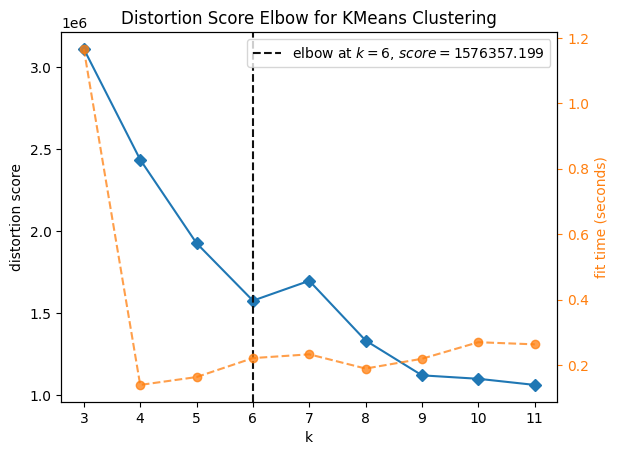

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [84]:
# 초기 k 값 참고를 위한 scree plot 을 그리고, 군집이 나뉘는 시간까지 고려한 k 값 확인 
model = KMeans()

# k 값의 범위를 조정해 줄 수 있습니다. 
visualizer = KElbowVisualizer(model, k=(3,12))

# 데이터 적용 
visualizer.fit(pca_df) 
visualizer.show()   

c:\Python\Python39\lib\site-packages\yellowbrick\cluster\icdm.py:390: DeprecationWarning:

the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)

c:\Python\Python39\lib\site-packages\yellowbrick\cluster\icdm.py:390: DeprecationWarning:

the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)

c:\Python\Python39\lib\site-packages\yellowbrick\cluster\icdm.py:390: DeprecationWarning:

the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)



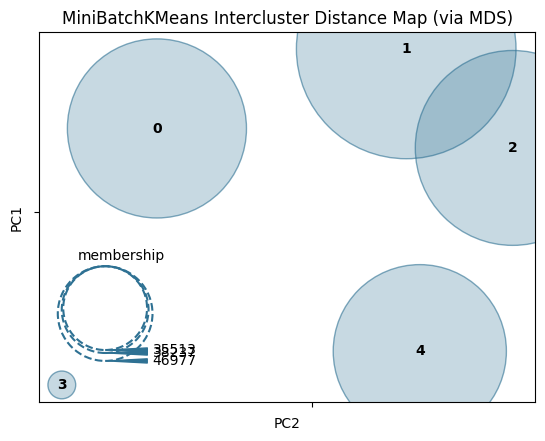

InterclusterDistance(ax=<Axes: title={'center': 'MiniBatchKMeans Intercluster Distance Map (via MDS)'}, xlabel='PC2', ylabel='PC1'>,
                     estimator=MiniBatchKMeans(n_clusters=5, random_state=42))

In [85]:
# 초기 k 값 참고를 위한 distance map 시각화
#그룹의 갯수를 지정해 줄 수 있습니다. 저는 5로 적어두었습니다. 
intercluster_distance(MiniBatchKMeans(5, random_state=42), pca_df)

In [86]:
#  KMEANS
# 군집개수(n_cluster)는 5,초기 중심 설정방식 랜덤,  
kmeans = KMeans(n_clusters=5, random_state=42, init='random')

# pca df 를 이용한 kmeans 알고리즘 적용
kmeans.fit(pca_df)

# 클러스터 번호 가져오기 
labels = kmeans.labels_

# 클러스터 번호가 할당된 데이터셋 생성
kmeans_df = pd.concat([pca_df, pd.DataFrame({'Cluster':labels})],axis = 1)

In [87]:
# 클러스터 번호가 할당된 데이터셋 생성
kmeans_df.groupby(['Cluster'])['PC1'].count().reset_index()

,Cluster,PC1
0,0,17059
1,1,38208
2,2,27781
3,3,33490
4,4,86978


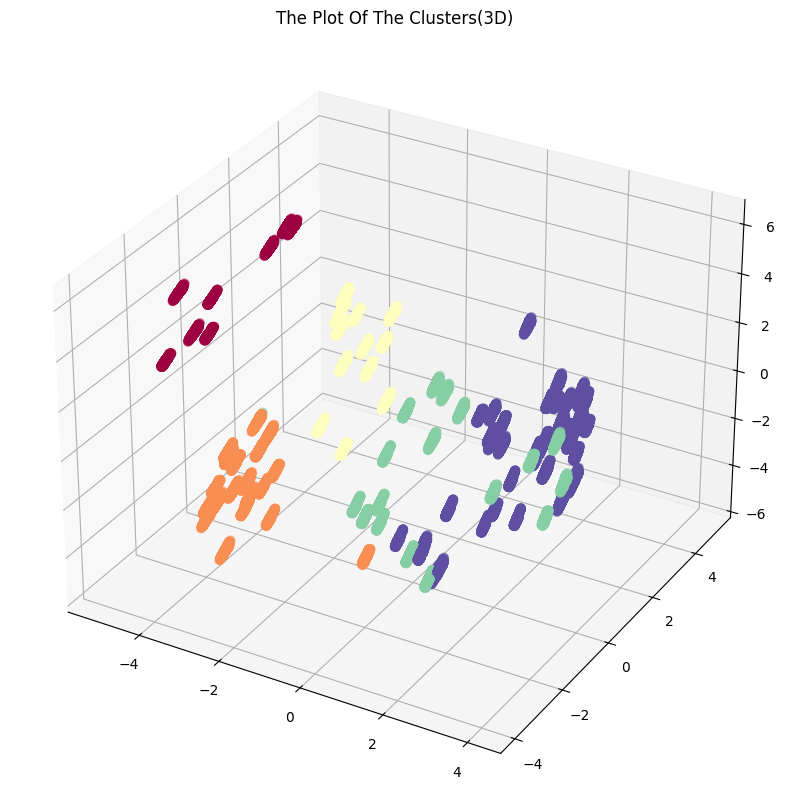

In [88]:
# 3차원으로 시각화 
x =kmeans_df["PC1"]
y =kmeans_df["PC2"]
z =kmeans_df["PC3"]

fig = plt.figure(figsize=(12,10))
ax = plt.subplot(111, projection='3d')
ax.scatter(x, y, z, s=40, c=kmeans_df["Cluster"], marker='o', alpha = 0.5, cmap = 'Spectral')
ax.set_title("The Plot Of The Clusters(3D)")

plt.show()

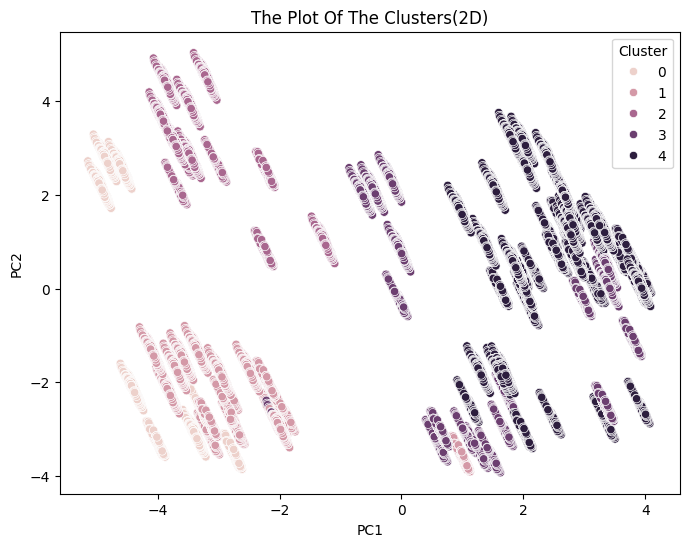

In [89]:
# 2차원으로 시각화

plt.figure(figsize=(8,6))

sns.scatterplot(data = kmeans_df, x = 'PC1', y='PC2', hue='Cluster')
plt.title('The Plot Of The Clusters(2D)')
plt.show()

# PART 5: LLM chatbot

https://teddylee777.github.io/langchain/rag-tutorial/